In [68]:
import pandas as pd

admissions = pd.read_csv('E:/mimic-iv/hosp/admissions.csv.gz')
patients = pd.read_csv('E:/mimic-iv/hosp/patients.csv.gz')
icustays = pd.read_csv('E:/mimic-iv/icu/icustays.csv.gz')

print("admissions:", admissions.shape)
print("patients:", patients.shape)
print("icustays:", icustays.shape)


admissions: (546028, 16)
patients: (364627, 6)
icustays: (94458, 8)


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

Was expecting a 1:1:1 ratio between the rows in the columns (i.e: one patient per column but that's clearly not the case)

In [3]:
from IPython.display import display

tables = ["admissions", "patients", "icustays"]


for table in tables:
    df = eval(table)
    print(f"{table} table:")
    display(df.head())

admissions table:


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


patients table:


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


icustays table:


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


Join key: subject_id column

**Goal**

* Predict LOS (length of stay in days)
* Readmission risk (Bern: Will they come back in 30 days? Probability?)

los column is given to us in icustays table:

but what is the unit of time? I am taking an educated guess that it is in days

Plot los to get an idea of distribution type

## Dataset Column Reference

### `admissions` table
- **subject_id**: Unique patient identifier (links to `patients` table)
- **hadm_id**: Unique hospital admission identifier (one patient can have multiple admissions)
- **admittime**: Date/time the patient was admitted to the hospital
- **dischtime**: Date/time the patient was discharged from the hospital
- **deathtime**: Date/time of death, if the patient died during this admission (NaN otherwise)
- **admission_type**: Category of admission (e.g. URGENT, EW EMER., ELECTIVE) — describes how/why the patient was admitted
- **admit_provider_id**: Identifier for the provider who admitted the patient
- **admission_location**: Where the patient was admitted from (e.g. EMERGENCY ROOM, TRANSFER FROM HOSPITAL)
- **discharge_location**: Where the patient was discharged to (e.g. HOME, HOSPICE)
- **insurance**: Patient's insurance type at time of admission (e.g. Medicaid, Medicare, Private)
- **language**: Patient's primary language
- **marital_status**: Patient's marital status (e.g. WIDOWED, SINGLE, MARRIED)
- **race**: Patient's recorded race/ethnicity (raw MIMIC categories — often 30+ distinct values)
- **edregtime**: Date/time the patient registered in the Emergency Department (if applicable)
- **edouttime**: Date/time the patient left the Emergency Department (if applicable)
- **hospital_expire_flag**: Binary flag — 1 if the patient died during this hospital admission, 0 otherwise

### `patients` table
- **subject_id**: Unique patient identifier (links to `admissions` and `icustays`)
- **gender**: Patient's recorded sex (M/F)
- **anchor_age**: Patient's age during `anchor_year` (not necessarily their age at any given admission — ages are de-identified/shifted)
- **anchor_year**: A de-identified reference year tied to `anchor_age`, used to calculate real elapsed time between events without revealing true calendar dates
- **anchor_year_group**: A 3-year range (e.g. "2014 - 2016") indicating roughly when `anchor_year` fell, for context without exact dates
- **dod**: Date of death, if known (NaN if patient is not recorded as deceased)

### `icustays` table
- **subject_id**: Unique patient identifier
- **hadm_id**: Hospital admission identifier this ICU stay belongs to
- **stay_id**: Unique identifier for this specific ICU stay (a patient can have multiple ICU stays per admission)
- **first_careunit**: ICU unit type the patient was first admitted to (e.g. MICU, SICU)
- **last_careunit**: ICU unit type the patient was in when the stay ended (may differ from `first_careunit` if transferred between ICU types)
- **intime**: Date/time the patient entered this ICU stay
- **outtime**: Date/time the patient left this ICU stay
- **los**: Length of stay in the ICU, in days (target variable for prediction)

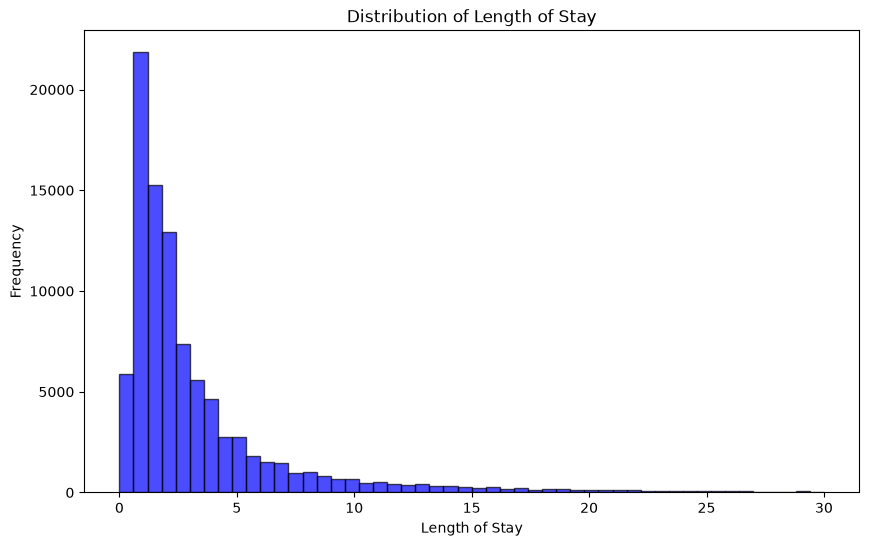

In [69]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(icustays['los'], bins=50, color='blue', alpha=0.7, edgecolor='black', range=(0, 30))
plt.xlabel('Length of Stay')
plt.ylabel('Frequency')
plt.title('Distribution of Length of Stay')
plt.show()

LOS looks like it follows an exponential distribution.

In [ ]:
icustays['los'].describe()

# E(X): 3.63
# STD: 5.4
# Rate: 1/3.63 = 0.275

count    94444.000000
mean         3.630025
std          5.402474
min          0.001250
25%          1.096212
50%          1.965648
75%          3.862575
max        226.403079
Name: los, dtype: float64

In [2]:
icustays.head(1)

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266


In [70]:
df = icustays.merge(admissions, on=['subject_id', 'hadm_id'], how='inner')
df = df.merge(patients, on='subject_id', how='inner')

df.shape
df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,...,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,F,52,2180,2014 - 2016,2180-09-09
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 18:02:00,2150-11-12 13:45:00,...,WIDOWED,WHITE,2150-11-02 11:41:00,2150-11-02 19:37:00,0,F,86,2150,2008 - 2010,2152-01-30
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 07:38:00,2189-07-03 03:00:00,...,MARRIED,BLACK/AFRICAN AMERICAN,2189-06-27 06:25:00,2189-06-27 08:42:00,0,F,73,2186,2008 - 2010,2193-08-26
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 22:56:00,2157-11-25 18:00:00,...,MARRIED,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,F,55,2157,2011 - 2013,NaN
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,2157-12-18 16:58:00,2157-12-24 14:55:00,...,MARRIED,WHITE,NaN,NaN,0,F,55,2157,2011 - 2013,NaN


In [72]:
df['admittime'] = pd.to_datetime(df['admittime'])
df['age_at_admission'] = df['anchor_age'] + (df['admittime'].dt.year - df['anchor_year'])

In [73]:
df['gender_binary'] = (df['gender'] == 'M').astype(int)

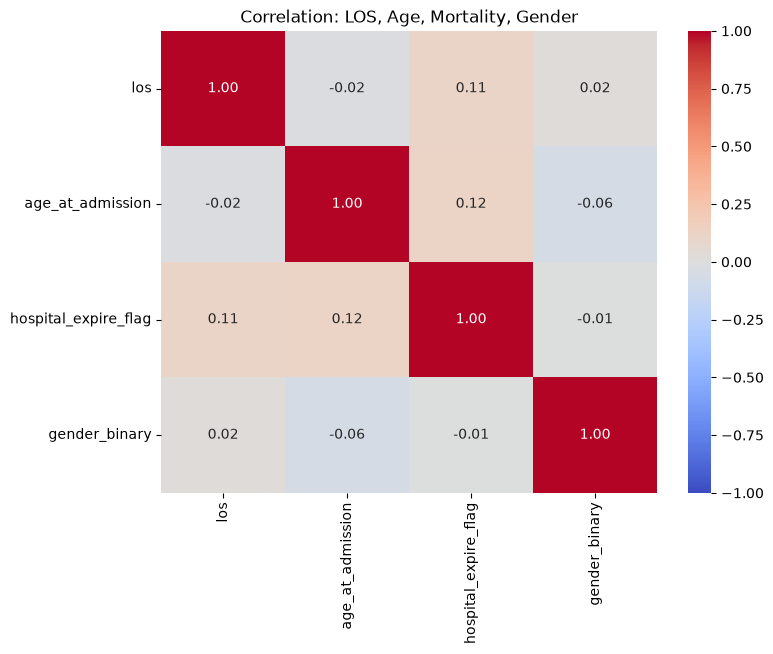

In [12]:
cols_of_interest = ['los', 'age_at_admission', 'hospital_expire_flag', 'gender_binary']
corr = df[cols_of_interest].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation: LOS, Age, Mortality, Gender')
plt.show()

In [74]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'gender',
       'anchor_age', 'anchor_year', 'anchor_year_group', 'dod',
       'age_at_admission', 'gender_binary'],
      dtype='str')

How does gender/race play a role in LOS?

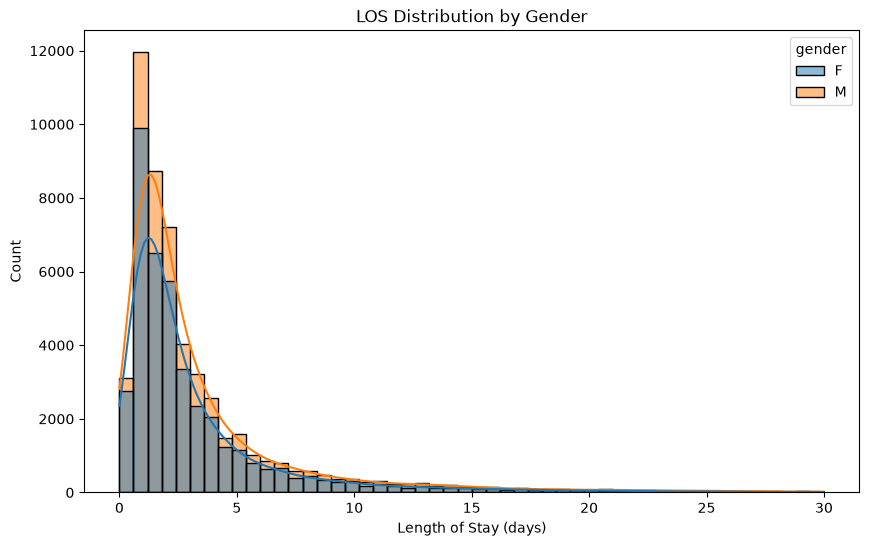

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='los', hue='gender', bins=50, kde=True, alpha=0.5,
             binrange=(0, 30), kde_kws={'clip': (0, 30)})
plt.title('LOS Distribution by Gender')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Count')
plt.show()

In [31]:
df.groupby('gender')['los'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,41577.0,3.510167,5.170790,0.001447,1.064109,1.941030,3.793657,159.666806
M,52867.0,3.724286,5.576163,0.001250,1.119201,1.984375,3.920417,226.403079


In [32]:
0.2*24

4.800000000000001

* More males than females (~21k more males)
* On average males LOS is longer by 0.2 days = 4.8 hours
* Males show more variance in LOS (lower min and higher max, potentially skewing the average)

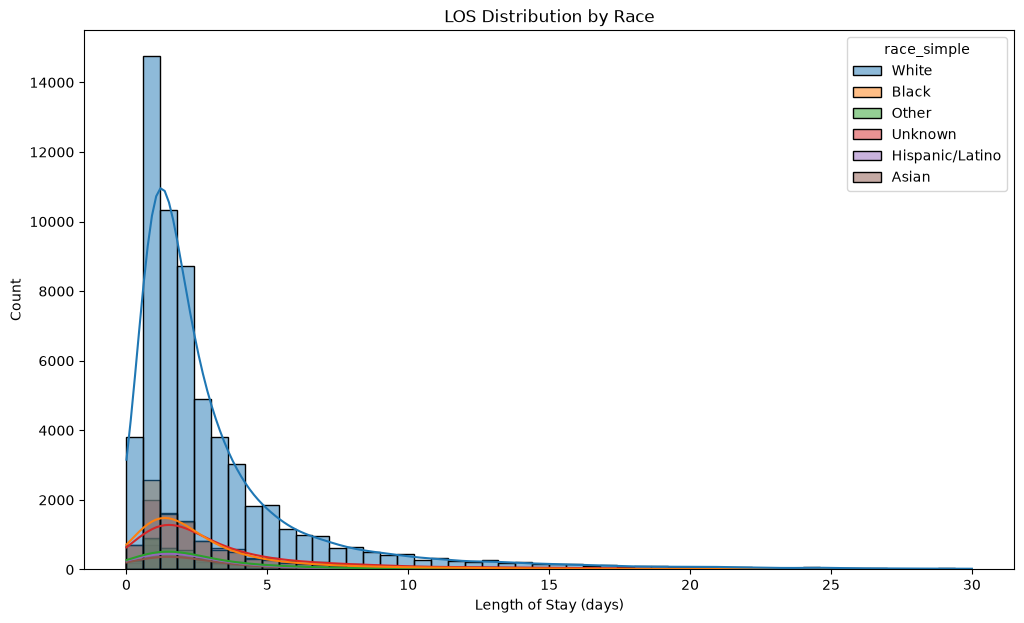

In [77]:
def simplify_race(race):
    race = race.upper()
    if 'WHITE' in race:
        return 'White'
    elif 'BLACK' in race:
        return 'Black'
    elif 'ASIAN' in race:
        return 'Asian'
    elif 'HISPANIC' in race or 'LATINO' in race:
        return 'Hispanic/Latino'
    elif 'UNKNOWN' in race or 'UNABLE' in race or 'DECLINED' in race:
        return 'Unknown'
    else:
        return 'Other'

df['race_simple'] = df['race'].apply(simplify_race)

# check the new distribution
df['race_simple'].value_counts()




plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='los', hue='race_simple', bins=50, kde=True, alpha=0.5,
             binrange=(0, 30), kde_kws={'clip': (0, 30)})
plt.title('LOS Distribution by Race')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Count')
plt.show()

In [35]:
df.groupby('race_simple')['los'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
race_simple,,,,,,,,
Unknown,10848.0,4.494622,6.332754,0.004421,1.203475,2.246649,4.944878,140.053669
Other,4068.0,3.775880,5.518680,0.005984,1.103617,2.005723,4.043770,81.755266
Asian,2885.0,3.622695,5.555758,0.009387,1.070613,1.910787,3.720544,77.740706
Black,10385.0,3.612661,5.603821,0.003461,1.032407,1.908553,3.762755,112.050741
Hispanic/Latino,3595.0,3.561112,5.899492,0.002419,1.076620,1.882222,3.692326,159.666806
White,62663.0,3.478049,5.127958,0.001250,1.094138,1.940949,3.740203,226.403079


Nothing crazy here, let's be more specific then:

In [36]:
df.groupby('race')['los'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
UNABLE TO OBTAIN,1881.0,4.721309,6.691350,0.004421,1.236111,2.357685,4.970752,86.848403
UNKNOWN,8452.0,4.517706,6.334206,0.014352,1.198692,2.269983,5.032740,140.053669
ASIAN - KOREAN,73.0,4.441330,7.418530,0.211354,1.265845,2.246898,3.903750,41.938299
PORTUGUESE,425.0,4.408925,7.739476,0.054618,1.144120,2.138090,4.205451,81.755266
BLACK/CARIBBEAN ISLAND,621.0,4.342569,6.971010,0.044502,1.107616,2.040150,3.982292,70.689225
AMERICAN INDIAN/ALASKA NATIVE,198.0,4.310959,6.482218,0.087870,1.102248,2.075770,4.714688,49.905231
HISPANIC/LATINO - COLUMBIAN,102.0,4.097819,8.500388,0.353611,1.078310,1.797332,3.808666,73.959120
HISPANIC/LATINO - DOMINICAN,746.0,4.097746,6.307410,0.049201,1.138860,2.131759,4.233325,64.184560
ASIAN - ASIAN INDIAN,248.0,4.079728,7.275491,0.160324,1.094034,1.902627,3.820246,66.267338


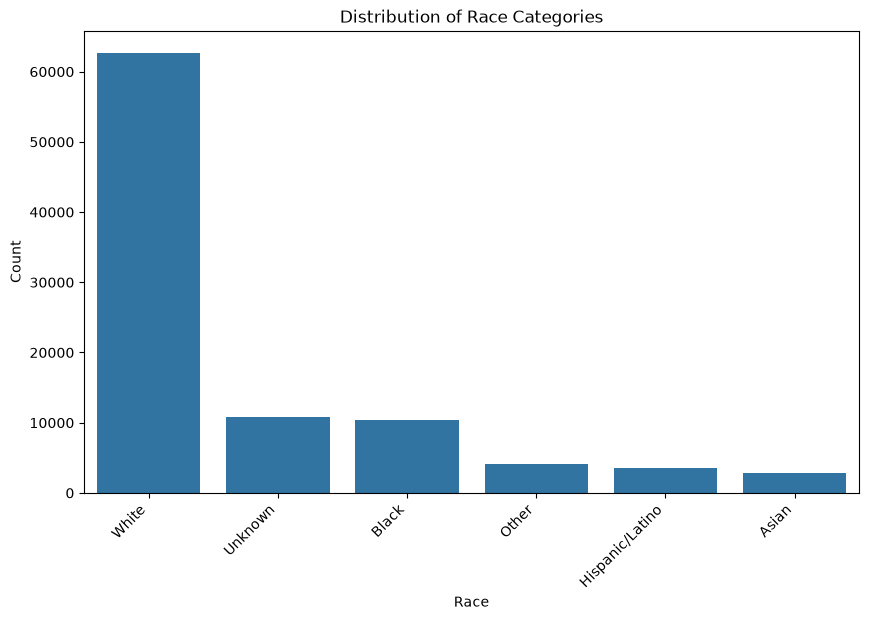

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='race_simple', order=df['race_simple'].value_counts().index)
plt.title('Distribution of Race Categories')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

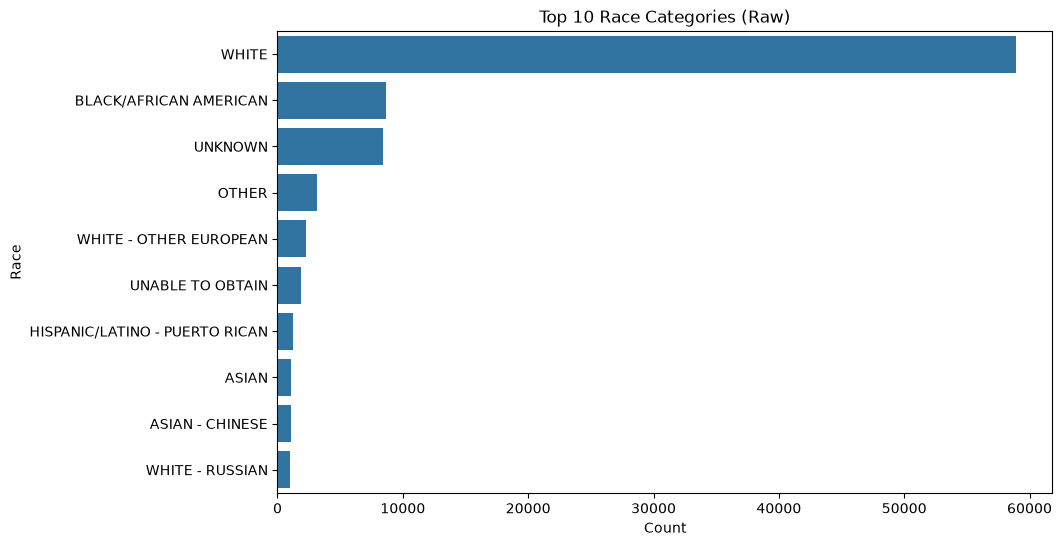

In [42]:
top_races = df['race'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_races.values, y=top_races.index)
plt.title('Top 10 Race Categories (Raw)')
plt.xlabel('Count')
plt.ylabel('Race')
plt.show()

I wonder if marital status plays a role in los:

In [43]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'gender',
       'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'race_simple'],
      dtype='str')

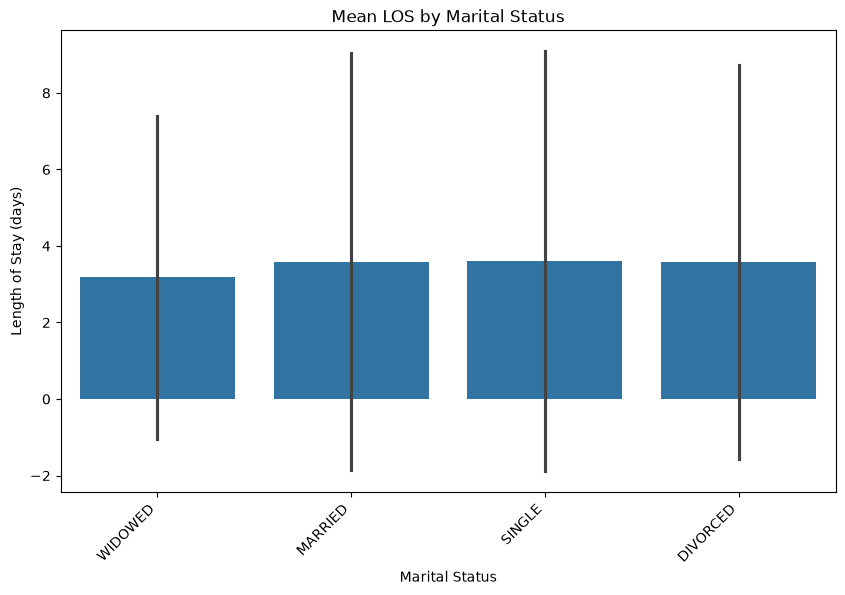

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='marital_status', y='los', errorbar='sd')
plt.title('Mean LOS by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.groupby('marital_status')['los'].mean().sort_values(ascending=False)

# Widowed individuals seem to stay the shortest by a huge margin, while divorced individuals stay the longest. 
# This could be due to various factors, including social support systems, health conditions, and access to care. 
# Further analysis would be needed to understand the underlying reasons for these differences in length of stay based on marital status.

marital_status
SINGLE      3.594429
MARRIED     3.593833
DIVORCED    3.577894
WIDOWED     3.179075
Name: los, dtype: float64

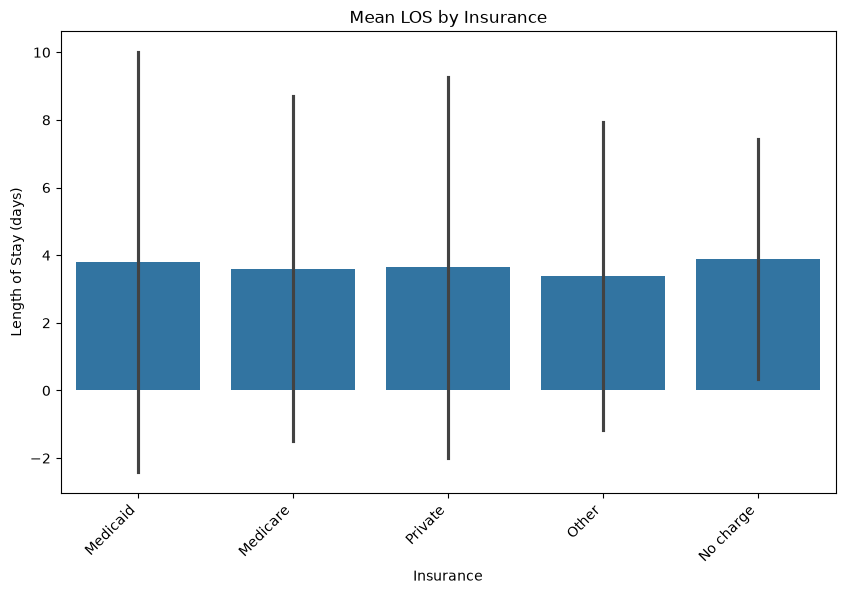

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='insurance', y='los', errorbar='sd')
plt.title('Mean LOS by Insurance')
plt.xlabel('Insurance')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.groupby('insurance')['los'].mean().sort_values(ascending=False)

# Those with no charge stay the longest, which could be due to various factors such as the severity of their conditions, lack of insurance leading to delayed care, 
# or other socioeconomic factors. Further analysis would be needed to understand the underlying reasons for these differences in length of stay based on insurance type.

insurance
No charge    3.874593
Medicaid     3.791910
Private      3.639239
Medicare     3.604113
Other        3.393845
Name: los, dtype: float64

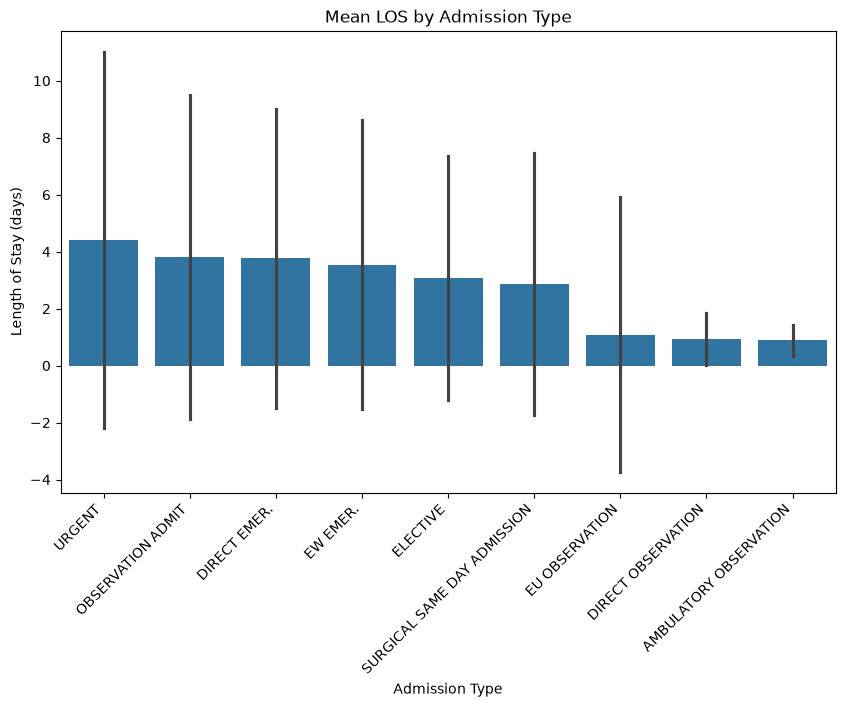

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='admission_type', y='los', errorbar='sd', order=df.groupby('admission_type')['los'].mean().sort_values(ascending=False).index)
plt.title('Mean LOS by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [55]:
df.groupby('admission_type')['los'].mean().sort_values(ascending=False)

# Describes why the patient is there and the severity, very abstract to me right now but intuitively those in urgent care stay the longest by far

admission_type
URGENT                         4.407848
OBSERVATION ADMIT              3.824740
DIRECT EMER.                   3.769731
EW EMER.                       3.543752
ELECTIVE                       3.088629
SURGICAL SAME DAY ADMISSION    2.869612
EU OBSERVATION                 1.085947
DIRECT OBSERVATION             0.924400
AMBULATORY OBSERVATION         0.886184
Name: los, dtype: float64

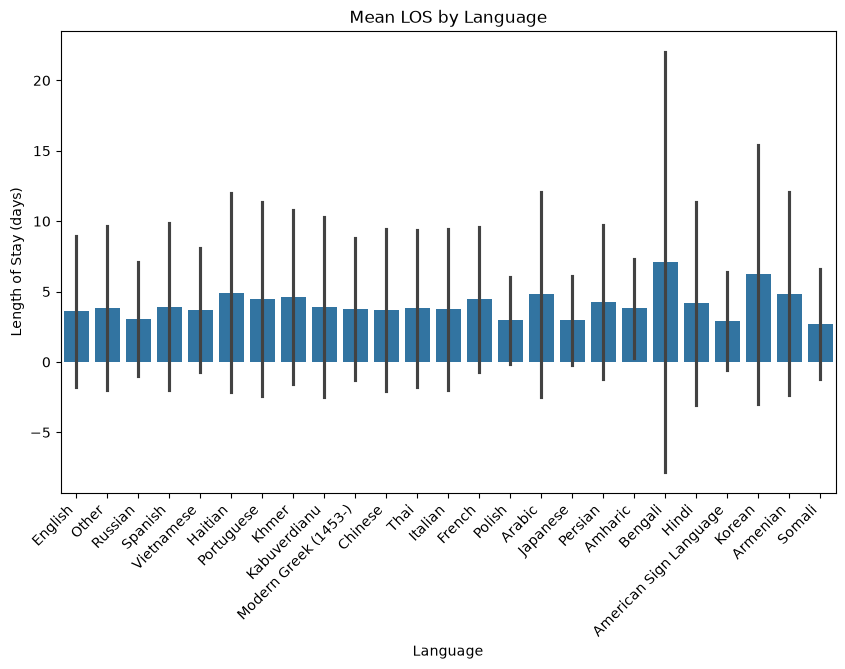

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='language', y='los', errorbar='sd')
plt.title('Mean LOS by Language')
plt.xlabel('Language')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.groupby('language')['los'].mean().sort_values(ascending=False)

# Highest variance is Bengali and highest mean, while Somali is lowest
# I wonder why there is so much variance in the languages when it comes to LOS. It could be due to various factors such as cultural differences, 
# access to healthcare, socioeconomic status, or other underlying health conditions. Further analysis would be needed to understand the reasons 
# behind these differences in length of stay based on language.

language
Bengali                   7.092401
Korean                    6.223909
Haitian                   4.918890
Armenian                  4.859551
Arabic                    4.811911
Khmer                     4.626540
Portuguese                4.485786
French                    4.458803
Persian                   4.249031
Hindi                     4.155413
Spanish                   3.935498
Kabuverdianu              3.897959
Other                     3.823010
Thai                      3.810232
Amharic                   3.802098
Modern Greek (1453-)      3.758326
Italian                   3.740794
Chinese                   3.705898
Vietnamese                3.659918
English                   3.596790
Russian                   3.078117
Japanese                  2.963713
Polish                    2.954031
American Sign Language    2.883554
Somali                    2.701465
Name: los, dtype: float64

Here's the full walkthrough of notebooks/real eda.ipynb, cell by cell, with the markdown notes (your own commentary) called out:




1. Data loading (code) — Loaded admissions, patients, icustays from MIMIC-IV. Shapes: 546,028 / 364,627 / 94,458 rows.




2. Markdown note:

> "Was expecting a 1:1:1 ratio between the rows in the columns (i.e: one patient per column but that's clearly not the case)"




→ Key finding: the three tables are not patient-level 1:1:1. patients (364,627) < admissions (546,028) means patients have multiple hospital admissions on average (~1.5x). icustays (94,458) is much smaller than admissions, meaning most hospital admissions never go to the ICU — only about 17% of admissions have an associated ICU stay. This is a structural fact that governs how you'll need to join/aggregate later (one patient → many admissions → zero or more ICU stays).




3. .head() display of all three tables (code) — confirmed column contents: admissions has admit/discharge times, admission type/location, demographics (insurance, language, marital status, race), death flag; patients has gender, age, anchor year, date of death; icustays has care unit, in/out times, and los.




4. Markdown note:

> "Join key: subject_id column"




→ Established subject_id as the linking key across all three tables (with hadm_id as the secondary key between admissions and icustays).




5. Markdown note — project goals:

> Goal

> - Predict LOS (length of stay in days)

> - Readmission risk (Bern: Will they come back in 30 days? Probability?)




→ This is the actual project scope statement: two modeling targets — (1) a regression on ICU length of stay, (2) a binary/Bernoulli classification (with probability output) for 30-day readmission.




6. Markdown note:

> "los column is given to us in icustays table: but what is the unit of time? I am taking an educated guess that it is in days. Plot los to get an idea of distribution type"




→ Flags an actual data-documentation gap — the unit of los isn't explicit in-notebook, and you're inferring "days" rather than confirming it from a data dictionary. Worth locking down before modeling (MIMIC-IV's official docs do confirm los is in days, fractional, computed from ICU in/out time — so your assumption is correct, but the notebook itself treats it as unverified).




7. Histogram (code) — plotted los distribution, 50 bins, range 0–50 days.




8. Markdown note:

> "LOS looks like it follows an exponential distribution."




→ Confirmed numerically (from the follow-up analysis I ran): mean 3.63 days vs. median 1.97 days, std 5.40, max 226.4 days, with 99% of stays under 26.4 days — classic right-skewed/exponential-like shape, validating your visual read.




9. Empty trailing cell — notebook stops here; no readmission-window logic, no merge of the three tables, and no missing-data audit yet (e.g., admissions has NaNs in deathtime, admission_location, discharge_location, insurance, language).




Overall state: exploration has established the join structure and confirmed the LOS target's distribution, but the two stated goals (LOS regression, 30-day readmission classification) have no modeling or even table-merging work started yet.

In [59]:
import pickle

with open('mimic_merged_eda.pkl', 'wb') as f:
    pickle.dump(df, f)

In [1]:
# Load back later

import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

with open('mimic_merged_eda.pkl', 'rb') as f:
    df = pickle.load(f)


df.to_pickle('mimic_merged_eda.pkl')
# and later:
df = pd.read_pickle('mimic_merged_eda.pkl')

In [2]:
df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod,race_simple
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,...,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,F,52,2180,2014 - 2016,2180-09-09,White
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 18:02:00,2150-11-12 13:45:00,...,WHITE,2150-11-02 11:41:00,2150-11-02 19:37:00,0,F,86,2150,2008 - 2010,2152-01-30,White
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 07:38:00,2189-07-03 03:00:00,...,BLACK/AFRICAN AMERICAN,2189-06-27 06:25:00,2189-06-27 08:42:00,0,F,73,2186,2008 - 2010,2193-08-26,Black
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 22:56:00,2157-11-25 18:00:00,...,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,F,55,2157,2011 - 2013,NaN,White
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,2157-12-18 16:58:00,2157-12-24 14:55:00,...,WHITE,NaN,NaN,0,F,55,2157,2011 - 2013,NaN,White


* * Feature Engineering / XGBoost Preparation 

In [75]:
result = df.columns.tolist()

for result in df:
    print(result + ": " + str(df[result].dtype))

subject_id: int64
hadm_id: int64
stay_id: int64
first_careunit: str
last_careunit: str
intime: str
outtime: str
los: float64
admittime: datetime64[us]
dischtime: str
deathtime: str
admission_type: str
admit_provider_id: str
admission_location: str
discharge_location: str
insurance: str
language: str
marital_status: str
race: str
edregtime: str
edouttime: str
hospital_expire_flag: int64
gender: str
anchor_age: int64
anchor_year: int64
anchor_year_group: str
dod: str
age_at_admission: int64
gender_binary: int64


In [ ]:
# see unique value counts for every categorical column, in one loop
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ({df[col].nunique()} unique values) ---")
    print(df[col].value_counts().head(10))

# which columns are low-cardinality (safe to one-hot) versus high-cardinality
# Turn these columns into categorical variables for modeling, and one-hot encode the low-cardinality ones. For high-cardinality ones, consider using embeddings or other techniques.
# XGBoost wants numeric values


--- first_careunit (17 unique values) ---
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
Name: count, dtype: int64

--- last_careunit (17 unique values) ---
last_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                        

C:\Users\icsti\AppData\Local\Temp\ipykernel_23476\2928953756.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [78]:
onehot_cols = ['admission_type', 'admission_location', 'insurance', 
               'marital_status', 'race_simple', 'first_careunit']

df_encoded = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# gender: just 2 categories, simpler to binary-map than one-hot
df_encoded['gender_binary'] = (df_encoded['gender'] == 'M').astype(int)

df_encoded.head()

,subject_id,hadm_id,stay_id,last_careunit,intime,outtime,los,admittime,dischtime,deathtime,...,first_careunit_Medicine/Cardiology Intermediate,first_careunit_Neuro Intermediate,first_careunit_Neuro Stepdown,first_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU),first_careunit_Neurology,first_careunit_PACU,first_careunit_Surgery/Trauma,first_careunit_Surgery/Vascular/Intermediate,first_careunit_Surgical Intensive Care Unit (SICU),first_careunit_Trauma SICU (TSICU)
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,...,False,False,False,False,False,False,False,False,False,False
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 18:02:00,2150-11-12 13:45:00,NaN,...,False,False,False,False,False,False,False,False,False,False
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 07:38:00,2189-07-03 03:00:00,NaN,...,False,False,False,False,False,False,False,False,False,False
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 22:56:00,2157-11-25 18:00:00,NaN,...,False,False,False,False,False,False,False,False,True,False
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,2157-12-18 16:58:00,2157-12-24 14:55:00,NaN,...,False,False,False,False,False,False,False,False,True,False


In [80]:
for col in df_encoded.columns:
    print(col + ": " + str(df_encoded[col].dtype))

subject_id: int64
hadm_id: int64
stay_id: int64
last_careunit: str
intime: str
outtime: str
los: float64
admittime: datetime64[us]
dischtime: str
deathtime: str
admit_provider_id: str
discharge_location: str
language: str
race: str
edregtime: str
edouttime: str
hospital_expire_flag: int64
gender: str
anchor_age: int64
anchor_year: int64
anchor_year_group: str
dod: str
age_at_admission: int64
gender_binary: int64
admission_type_DIRECT EMER.: bool
admission_type_DIRECT OBSERVATION: bool
admission_type_ELECTIVE: bool
admission_type_EU OBSERVATION: bool
admission_type_EW EMER.: bool
admission_type_OBSERVATION ADMIT: bool
admission_type_SURGICAL SAME DAY ADMISSION: bool
admission_type_URGENT: bool
admission_location_CLINIC REFERRAL: bool
admission_location_EMERGENCY ROOM: bool
admission_location_INFORMATION NOT AVAILABLE: bool
admission_location_INTERNAL TRANSFER TO OR FROM PSYCH: bool
admission_location_PACU: bool
admission_location_PHYSICIAN REFERRAL: bool
admission_location_PROCEDURE SIT

In [8]:
df_encoded['gender'].value_counts()

gender
M    52875
F    41583
Name: count, dtype: int64

In [ ]:
df_encoded['gender_binary'].value_counts()
# 1: Male
# 2: Female


gender_binary
1    52875
0    41583
Name: count, dtype: int64

 Average admit hour: 12.57
 Average admit hour: 14.00


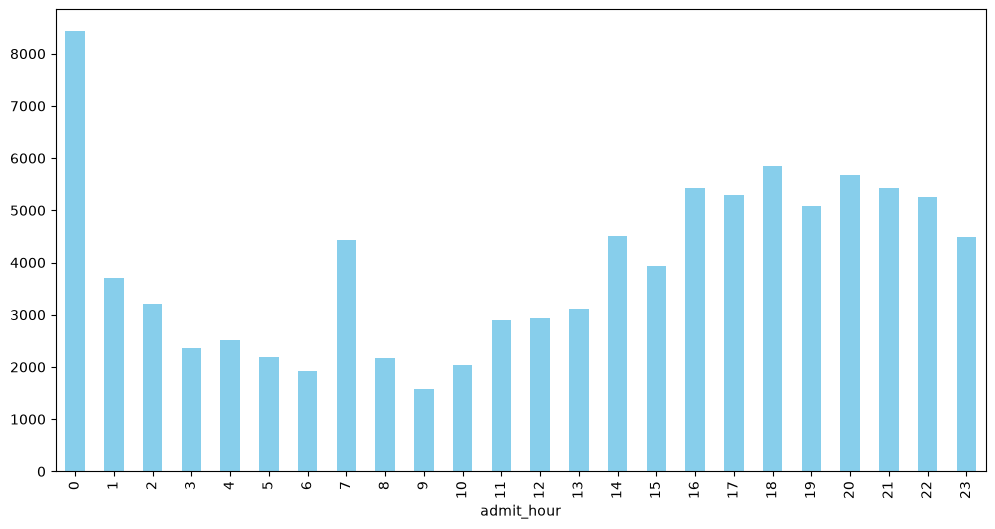

In [ ]:
# Hour of admission transformation to 24 hours

df_encoded['admit_hour'] = pd.to_datetime(df_encoded['admittime']).dt.hour

df_encoded['admit_hour'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6), color='skyblue')

print(f' Average admit hour: {df_encoded["admit_hour"].mean():.2f}')
print(f' Average admit hour: {df_encoded["admit_hour"].median():.2f}')

# So, around 12:57 P.M. Average
# 2 P.M for median (sligt skew)

 Average admit day of week: 3.00
 Average admit day of week: 3.00


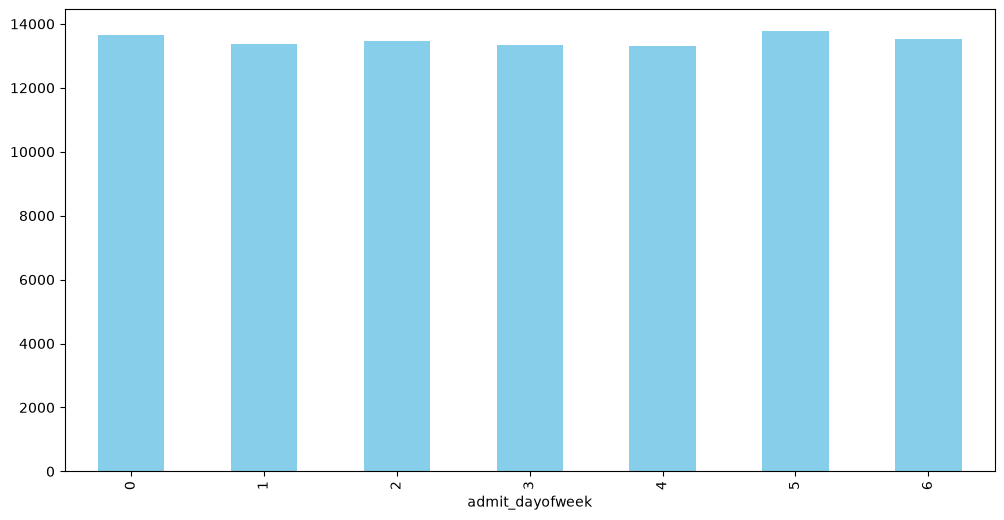

In [ ]:
df_encoded['admit_dayofweek'] = pd.to_datetime(df_encoded['admittime']).dt.dayofweek

df_encoded['admit_dayofweek'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6), color='skyblue')

print(f' Average admit day of week: {df_encoded["admit_dayofweek"].mean():.2f}')
print(f' Average admit day of week: {df_encoded["admit_dayofweek"].median():.2f}')

# 1/n for all days


 Average ED duration: 6.38 hours
 Median ED duration: 5.25 hours


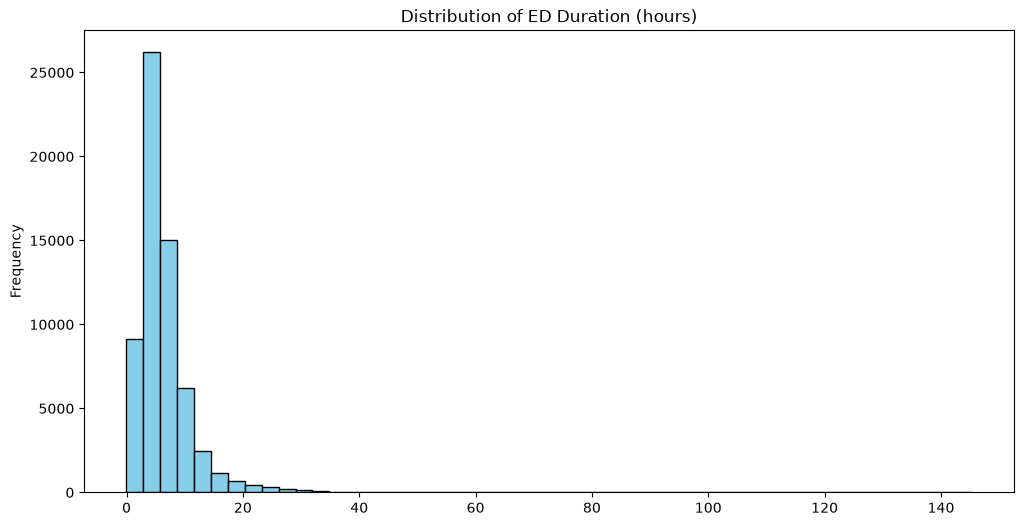

In [13]:
# Duration:

df_encoded['ed_duration_hours'] = (pd.to_datetime(df_encoded['edouttime']) - pd.to_datetime(df_encoded['edregtime'])).dt.total_seconds() / 3600

df_encoded['ed_duration_hours'].plot(kind='hist', bins=50, figsize=(12, 6), color='skyblue', edgecolor='black')
plt.title('Distribution of ED Duration (hours)')

print(f' Average ED duration: {df_encoded["ed_duration_hours"].mean():.2f} hours')
print(f' Median ED duration: {df_encoded["ed_duration_hours"].median():.2f} hours')

In [15]:
import os
print(os.getcwd())

e:\MedAgent\notebooks


In [19]:
df_encoded.to_pickle('mimic_encoded_features.pkl')

In [ ]:
import pandas as pd
df_encoded = pd.read_pickle('mimic_encoded_features.pkl')




df_encoded.to_pickle(r'E:\MedAgent\mimic_encoded_features.pkl')
# and later:
df_encoded = pd.read_pickle(r'E:\MedAgent\mimic_encoded_features.pkl')

In [1]:
import pandas as pd
df_encoded = pd.read_pickle('mimic_encoded_features.pkl')

# run next

In [17]:
os.listdir()

['demo eda.ipynb', 'mimic_merged_eda.pkl', 'real eda.ipynb']

In [9]:
df_encoded.head(1)

,subject_id,hadm_id,stay_id,last_careunit,intime,outtime,los,admittime,dischtime,deathtime,...,first_careunit_Neurology,first_careunit_PACU,first_careunit_Surgery/Trauma,first_careunit_Surgery/Vascular/Intermediate,first_careunit_Surgical Intensive Care Unit (SICU),first_careunit_Trauma SICU (TSICU),gender_binary,admit_hour,admit_dayofweek,ed_duration_hours
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,...,False,False,False,False,False,False,0,12,6,8.1


In [8]:
i=0
for column in df_encoded.columns:
    i+= 1
    print(f"{i} {column}: {df_encoded[column].iloc[0]}")
    

1 subject_id: 10000032
2 hadm_id: 29079034
3 stay_id: 39553978
4 last_careunit: Medical Intensive Care Unit (MICU)
5 intime: 2180-07-23 14:00:00
6 outtime: 2180-07-23 23:50:47
7 los: 0.4102662037037037
8 admittime: 2180-07-23 12:35:00
9 dischtime: 2180-07-25 17:55:00
10 deathtime: nan
11 admit_provider_id: P06OTX
12 discharge_location: HOME
13 language: English
14 race: WHITE
15 edregtime: 2180-07-23 05:54:00
16 edouttime: 2180-07-23 14:00:00
17 hospital_expire_flag: 0
18 gender: F
19 anchor_age: 52
20 anchor_year: 2180
21 anchor_year_group: 2014 - 2016
22 dod: 2180-09-09
23 admission_type_DIRECT EMER.: False
24 admission_type_DIRECT OBSERVATION: False
25 admission_type_ELECTIVE: False
26 admission_type_EU OBSERVATION: False
27 admission_type_EW EMER.: True
28 admission_type_OBSERVATION ADMIT: False
29 admission_type_SURGICAL SAME DAY ADMISSION: False
30 admission_type_URGENT: False
31 admission_location_CLINIC REFERRAL: False
32 admission_location_EMERGENCY ROOM: True
33 admission_loc

* To Drop:

Drop IDs/ raw text / leakage

In [12]:
drop_cols = ['subject_id', 'hadm_id', 'stay_id', 'last_careunit', 'discharge_location',
             'language', 'race', 'admit_provider_id', 'gender',
             'intime', 'outtime', 'admittime', 'dischtime', 'deathtime', 'dod',
             'edregtime', 'edouttime', 'anchor_year', 'anchor_year_group',
             'hospital_expire_flag']

model_df = df_encoded.drop(columns=drop_cols)
model_df.iloc[0]

los                                                                0.410266
anchor_age                                                               52
admission_type_DIRECT EMER.                                           False
admission_type_DIRECT OBSERVATION                                     False
admission_type_ELECTIVE                                               False
admission_type_EU OBSERVATION                                         False
admission_type_EW EMER.                                                True
admission_type_OBSERVATION ADMIT                                      False
admission_type_SURGICAL SAME DAY ADMISSION                            False
admission_type_URGENT                                                 False
admission_location_CLINIC REFERRAL                                    False
admission_location_EMERGENCY ROOM                                      True
admission_location_INFORMATION NOT AVAILABLE                          False
admission_lo

In [ ]:
# convert booleans to int

bool_cols =model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

model_df.iloc[0]

# False: 0
# True: 1

los                                                                 0.410266
anchor_age                                                         52.000000
admission_type_DIRECT EMER.                                         0.000000
admission_type_DIRECT OBSERVATION                                   0.000000
admission_type_ELECTIVE                                             0.000000
admission_type_EU OBSERVATION                                       0.000000
admission_type_EW EMER.                                             1.000000
admission_type_OBSERVATION ADMIT                                    0.000000
admission_type_SURGICAL SAME DAY ADMISSION                          0.000000
admission_type_URGENT                                               0.000000
admission_location_CLINIC REFERRAL                                  0.000000
admission_location_EMERGENCY ROOM                                   1.000000
admission_location_INFORMATION NOT AVAILABLE                        0.000000

In [14]:
import numpy as np
bad_mask = model_df['los'].isna() | np.isinf(model_df['los'])

print(f'dropped rows: {bad_mask.sum()} out of {len(model_df)}')

model_df = model_df[~bad_mask]


X = model_df.drop(columns=['los'])
y = model_df['los']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dropped rows: 14 out of 94458


In [16]:
import numpy as np

print(y_train.isna().sum())
print(np.isinf(y_train).sum())
print(y_train.describe())

12
0
count    75554.000000
mean         3.624041
std          5.344052
min          0.001250
25%          1.096597
50%          1.966858
75%          3.868041
max        226.403079
Name: los, dtype: float64


In [22]:
import xgboost as xgb 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


model = xgb.XGBRegressor( n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# n estimators = number of trees
# max depth = maximum depth of each tree
# learning rate = step size shrinkage used to prevent overfitting
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)    
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 27.2159
Root Mean Squared Error (RMSE): 5.2169
R-squared (R2): 0.0425


RMSE: off by 5.2 days

Need to fix model_df

In [27]:
i=0

for column in model_df.columns:
    i+= 1
    print(f"{i} {column}: {model_df[column].iloc[0]} - data type: {model_df[column].dtype}")

1 los: 0.4102662037037037 - data type: float64
2 anchor_age: 52 - data type: int64
3 admission_type_DIRECT EMER.: 0 - data type: int64
4 admission_type_DIRECT OBSERVATION: 0 - data type: int64
5 admission_type_ELECTIVE: 0 - data type: int64
6 admission_type_EU OBSERVATION: 0 - data type: int64
7 admission_type_EW EMER.: 1 - data type: int64
8 admission_type_OBSERVATION ADMIT: 0 - data type: int64
9 admission_type_SURGICAL SAME DAY ADMISSION: 0 - data type: int64
10 admission_type_URGENT: 0 - data type: int64
11 admission_location_CLINIC REFERRAL: 0 - data type: int64
12 admission_location_EMERGENCY ROOM: 1 - data type: int64
13 admission_location_INFORMATION NOT AVAILABLE: 0 - data type: int64
14 admission_location_INTERNAL TRANSFER TO OR FROM PSYCH: 0 - data type: int64
15 admission_location_PACU: 0 - data type: int64
16 admission_location_PHYSICIAN REFERRAL: 0 - data type: int64
17 admission_location_PROCEDURE SITE: 0 - data type: int64
18 admission_location_TRANSFER FROM HOSPITAL: 0

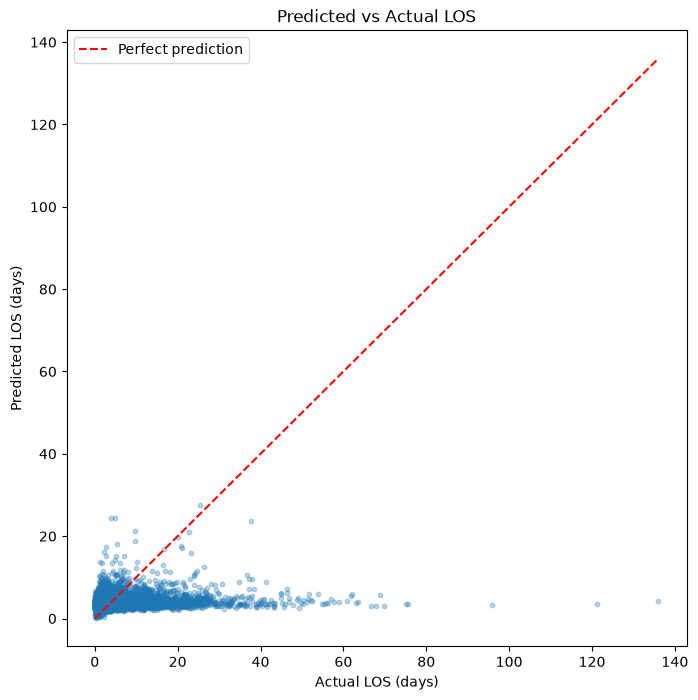

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual LOS (days)')
plt.ylabel('Predicted LOS (days)')
plt.title('Predicted vs Actual LOS')
plt.legend()
plt.show()

# Prediction vs actual plot

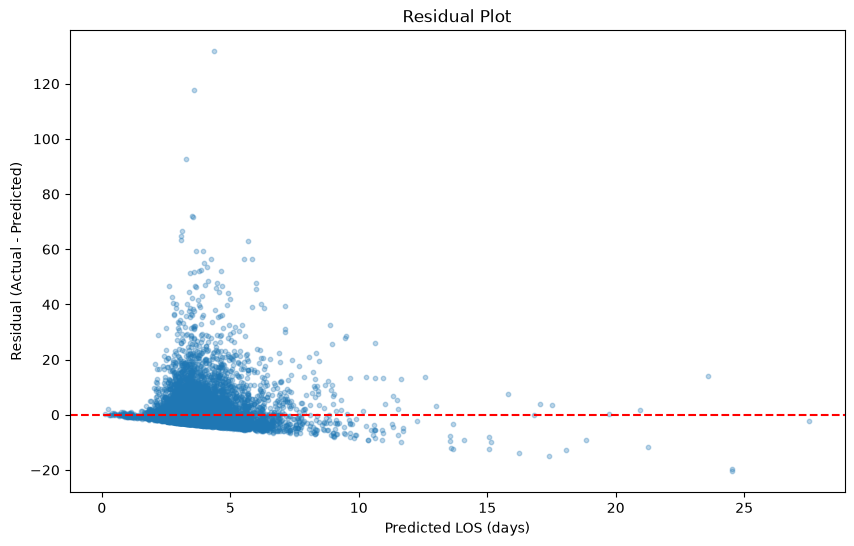

In [26]:
#plot residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted LOS (days)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [29]:
for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame):
        print(name, val.shape)

___ (1, 72)
df_encoded (94458, 72)
_3 (5, 72)
_9 (1, 72)
model_df (94444, 52)
X (94444, 51)
X_train (75555, 51)
X_test (18889, 51)


In [33]:
import os
print(os.listdir('E:/mimic-iv/hosp'))
print(os.listdir('E:/mimic-iv/icu'))

['admissions.csv.gz', 'patients.csv.gz']
['icustays.csv.gz']


In [9]:
i=0

for column in df_encoded.columns:
    i+= 1
    print(f"{i} {column}: {df_encoded[column].iloc[0]} - data type: {df_encoded[column].dtype}")

1 subject_id: 10000032 - data type: int64
2 hadm_id: 29079034 - data type: int64
3 stay_id: 39553978 - data type: int64
4 last_careunit: Medical Intensive Care Unit (MICU) - data type: str
5 intime: 2180-07-23 14:00:00 - data type: str
6 outtime: 2180-07-23 23:50:47 - data type: str
7 los: 0.4102662037037037 - data type: float64
8 admittime: 2180-07-23 12:35:00 - data type: str
9 dischtime: 2180-07-25 17:55:00 - data type: str
10 deathtime: nan - data type: str
11 admit_provider_id: P06OTX - data type: str
12 discharge_location: HOME - data type: str
13 language: English - data type: str
14 race: WHITE - data type: str
15 edregtime: 2180-07-23 05:54:00 - data type: str
16 edouttime: 2180-07-23 14:00:00 - data type: str
17 hospital_expire_flag: 0 - data type: int64
18 gender: F - data type: str
19 anchor_age: 52 - data type: int64
20 anchor_year: 2180 - data type: int64
21 anchor_year_group: 2014 - 2016 - data type: str
22 dod: 2180-09-09 - data type: str
23 admission_type_DIRECT EMER.:

In [15]:
i=0

for column in model_df.columns:
    i+= 1
    print(f"{i} {column}: {model_df[column].iloc[0]} - data type: {model_df[column].dtype}")

1 los: 0.4102662037037037 - data type: float64
2 anchor_age: 52 - data type: int64
3 admission_type_DIRECT EMER.: False - data type: bool
4 admission_type_DIRECT OBSERVATION: False - data type: bool
5 admission_type_ELECTIVE: False - data type: bool
6 admission_type_EU OBSERVATION: False - data type: bool
7 admission_type_EW EMER.: True - data type: bool
8 admission_type_OBSERVATION ADMIT: False - data type: bool
9 admission_type_SURGICAL SAME DAY ADMISSION: False - data type: bool
10 admission_type_URGENT: False - data type: bool
11 admission_location_CLINIC REFERRAL: False - data type: bool
12 admission_location_EMERGENCY ROOM: True - data type: bool
13 admission_location_INFORMATION NOT AVAILABLE: False - data type: bool
14 admission_location_INTERNAL TRANSFER TO OR FROM PSYCH: False - data type: bool
15 admission_location_PACU: False - data type: bool
16 admission_location_PHYSICIAN REFERRAL: False - data type: bool
17 admission_location_PROCEDURE SITE: False - data type: bool
18 a

In [16]:
# First model may not be accurate as patients can have multiple ICU stays
# Fix by splitting patient via ID


from sklearn.model_selection import GroupShuffleSplit

groups = df_encoded.loc[model_df.index, 'subject_id'] # patient id for each row

X = model_df.drop(columns=['los']) # Features
y = model_df['los'] # Target variable


gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# check for overlaps
intersection = set(X_train.index).intersection(set(X_test.index))
print(f"Number of overlapping indices between train and test sets: {len(intersection)}")

Number of overlapping indices between train and test sets: 0


In [17]:
# use z = ln(y) due to skewness of LOS distribution, which is common in healthcare data. 
# This transformation can help stabilize variance and make the data more normally distributed, which can improve model performance.
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_train_log = np.log1p(y_train)  # log( y) to handle zero values
y_test_log = np.log1p(y_test)  # log(y) to handle zero values

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

model.fit(X_train, y_train_log)

z_pred_log = model.predict(X_test) 

y_pred = np.exp(z_pred_log)

r2_log = r2_score(y_test, y_pred)
print(f"R-squared (R2) after log transformation: {r2_log:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


R-squared (R2) after log transformation: 0.0352
Mean Absolute Error (MAE): 2.8568
Root Mean Squared Error (RMSE): 5.4668


### Baseline LOS model — metric interpretation (log-target XGBoost)

**Note:** R² is on the ln(LOS) scale; MAE and RMSE are on the raw (days) scale — don't compare across scales.

- **MAE = 2.8568** → On a typical patient, predictions miss by ~2.86 days.
  This is the honest human-facing number. Median LOS is ~2 days, so a ~2.86-day
  miss is large relative to a typical stay — features are weak.

- **RMSE = 5.4668** → Root-mean-squared error in days. Because errors are squared
  before averaging, RMSE is dominated by a few huge misses (the rare 100–226 day
  stays). The naive "always predict the mean" model has RMSE ≈ std(LOS) ≈ 5.34 days,
  so we're basically at the dumb baseline on this metric — expected, since we
  optimized log/percentage error and predict medians, not the long-stay outliers.

- **RMSE / MAE = 5.4668 / 2.8568 = 1.914** → Fat-tail diagnostic. For Gaussian
  errors this ratio would be sqrt(π/2) ≈ 1.253. We're well above that, meaning most
  predictions are decent but a handful of long-stay patients are wildly off.

- **R² = 0.0352 (ln scale)** → Features explain only ~3.5% of the variance in
  ln(LOS); SS_res / SS_tot = 1 − 0.0352 = 0.9648, i.e. 96.5% of the mean-model's
  error remains. Demographics capture *who the patient is*, not *how sick they are*.

**Takeaway:** machinery is correct; bottleneck is features. Next: add clinical
signal (diagnoses_icd comorbidities, then first-24h labs/vitals).

In [55]:
diagnoses = pd.read_csv('E:/mimic-iv/mimic-iv-3.1/hosp/diagnoses_icd.csv.gz')

diagnoses.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


<Axes: xlabel='seq_num'>

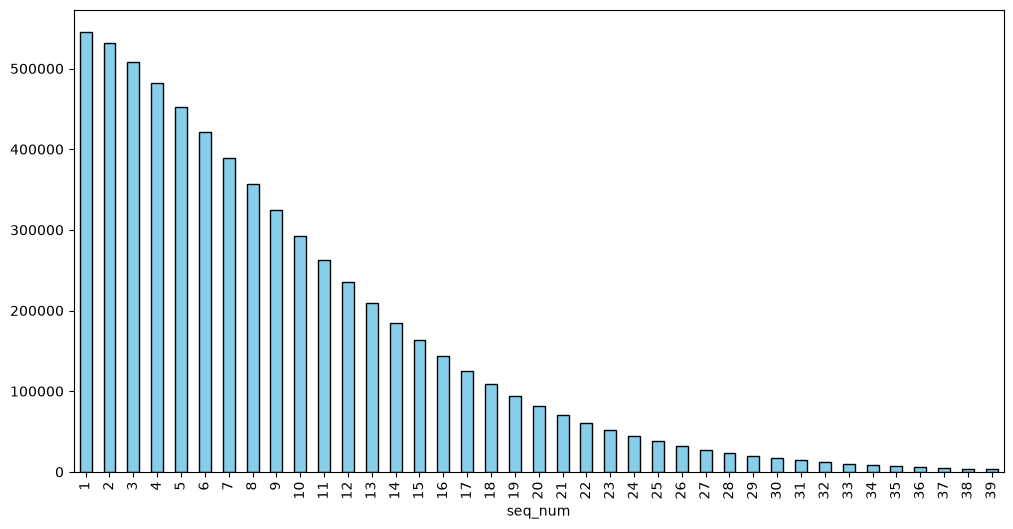

In [56]:
diagnoses['seq_num'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6), color='skyblue', edgecolor='black')

# - seq_num is the ranking of diagnoses (1 = most imortant, 2 = second most important, etc.) for a given hospital admission.

In [47]:
diagnoses['icd_version'].nunique()

2

In [48]:
print(list(set(diagnoses['icd_version'])))

[9, 10]


In [ ]:
dx_count = diagnoses.groupby('hadm_id').size().reset_index(name='num_diagnoses')

print(dx_count.shape)


print(f'unique num_diagnoses values: {dx_count["num_diagnoses"].nunique()}')
dx_count.head()
# num_diagnoses = a count feature: more codes ≈ more comorbidities ≈ sicker patient
# basically, how many times a patient has came in again

(545497, 2)
unique num_diagnoses values: 42


,hadm_id,num_diagnoses
0,20000019,12
1,20000024,10
2,20000034,28
3,20000041,10
4,20000045,16


In [60]:
# Merge the count onto your main dataframe by admission ID.
# how='left' keeps every row of df; admissions with no diagnosis codes get NaN.
df = df.drop(columns=['num_diagnoses'], errors='ignore')  # Drop if exists to avoid duplicates
df = df.merge(dx_count, on='hadm_id', how='left')

# Fill any missing counts with 0 (no codes recorded = 0 diagnoses)
df['num_diagnoses'] = df['num_diagnoses'].fillna(0).astype(int)

print(df['num_diagnoses'].describe())

count    94458.000000
mean        18.624595
std          9.105365
min          0.000000
25%         12.000000
50%         17.000000
75%         24.000000
max         39.000000
Name: num_diagnoses, dtype: float64


<Axes: xlabel='num_diagnoses'>

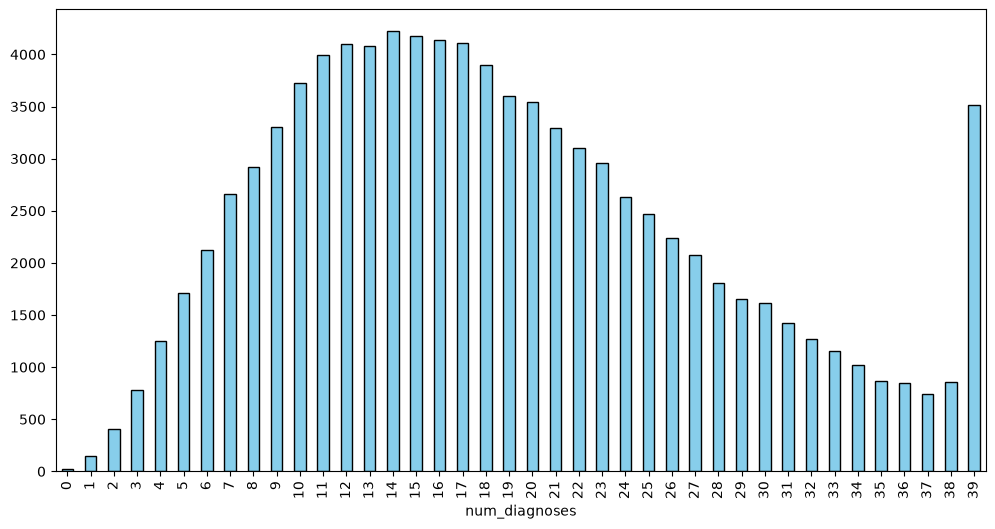

In [61]:
df['num_diagnoses'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6), color='skyblue', edgecolor='black')

In [62]:
# how many admissions does a single patient have?
diagnoses.groupby('subject_id')['hadm_id'].nunique().describe()
# you'll see plenty of patients with >1 admission — that's the whole reason

count    223291.000000
mean          2.442987
std           3.573275
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max         238.000000
Name: hadm_id, dtype: float64

In [41]:
# Re-load and check the raw table size first
diagnoses = pd.read_csv('E:/mimic-iv/hosp/diagnoses_icd.csv.gz')  # fix path if needed

print("diagnoses rows:", len(diagnoses))                    # expect ~6 million
print("unique admissions:", diagnoses['hadm_id'].nunique()) # expect ~430,000
diagnoses.head()

diagnoses rows: 4506
unique admissions: 275


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


In [44]:
# Read straight from the Downloads location where the full extract lives

# admissions = pd.read_csv('E:/mimic-iv/hosp/admissions.csv.gz')
#diagnoses = pd.read_csv(f'{BASE}/hosp/diagnoses_icd.csv.gz')

diagnoses = pd.read_csv('E:/mimic-iv/mimic-iv-3.1/hosp/diagnoses_icd.csv.gz')

print("diagnoses rows:", len(diagnoses))                     # want ~6,000,000
print("unique admissions:", diagnoses['hadm_id'].nunique())  # want ~430,000
diagnoses.head()

diagnoses rows: 6364488
unique admissions: 545497


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [53]:
df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod,num_diagnoses_x,num_diagnoses_y,num_diagnoses
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,...,2180-07-23 14:00:00,0,F,52,2180,2014 - 2016,2180-09-09,13,13.0,13
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 18:02:00,2150-11-12 13:45:00,...,2150-11-02 19:37:00,0,F,86,2150,2008 - 2010,2152-01-30,0,NaN,22
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 07:38:00,2189-07-03 03:00:00,...,2189-06-27 08:42:00,0,F,73,2186,2008 - 2010,2193-08-26,0,NaN,15
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 22:56:00,2157-11-25 18:00:00,...,2157-11-19 01:24:00,0,F,55,2157,2011 - 2013,NaN,10,10.0,10
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,2157-12-18 16:58:00,2157-12-24 14:55:00,...,NaN,0,F,55,2157,2011 - 2013,NaN,7,7.0,7


In [67]:
print('num_diagnoses' in df.columns)   # must be True
print('num_diagnoses' in df_encoded.columns)   # should now be True
print('num_diagnoses' in model_df.columns)   # should FINALLY be True

True
False
False


In [83]:
# Inventory every key dataframe in one shot.
# We reference them by NAME (string) so we can skip any that don't exist yet.

frames = ['df', 'df_encoded', 'model_df', 'dx_count', 'diagnoses']

for name in frames:
    # globals() is the dict of all variables in the notebook.
    # .get(name) returns the dataframe if it exists, or None if it doesn't —
    # this way the loop won't crash on a frame you haven't built yet.
    frame = globals().get(name)

    if frame is None:
        print(f"{name}: NOT DEFINED\n")
        continue

    print(f"=== {name} ===")
    print(f"  shape: {frame.shape}")
    print(f"  has num_diagnoses: {'num_diagnoses' in frame.columns}")
    print(f"  columns ({len(frame.columns)}): {list(frame.columns)}")
    print()

=== df ===
  shape: (94458, 30)
  has num_diagnoses: False
  columns (30): ['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'age_at_admission', 'gender_binary', 'race_simple']

=== df_encoded ===
  shape: (94458, 70)
  has num_diagnoses: False
  columns (70): ['subject_id', 'hadm_id', 'stay_id', 'last_careunit', 'intime', 'outtime', 'los', 'admittime', 'dischtime', 'deathtime', 'admit_provider_id', 'discharge_location', 'language', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'age_at_admission', 'gender_binary', 'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVA

In [84]:
# 1. Merge dx_count into the CURRENT df (idempotent: drop first so re-running is safe)
df = df.drop(columns=['num_diagnoses'], errors='ignore')
df = df.merge(dx_count, on='hadm_id', how='left')
df['num_diagnoses'] = df['num_diagnoses'].fillna(0).astype(int)
print('df:', 'num_diagnoses' in df.columns, '| shape:', df.shape)   # want True, (94458, 31)

df: True | shape: (94458, 31)


In [85]:
# 2. Rebuild df_encoded from the now-merged df
onehot_cols = ['admission_type', 'admission_location', 'insurance',
               'marital_status', 'race_simple', 'first_careunit']
df_encoded = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
df_encoded['gender_binary'] = (df_encoded['gender'] == 'M').astype(int)
print('df_encoded:', 'num_diagnoses' in df_encoded.columns)          # want True

df_encoded: True


In [86]:
df_encoded['admit_hour'] = pd.to_datetime(df_encoded['admittime']).dt.hour
df_encoded['admit_dayofweek'] = pd.to_datetime(df_encoded['admittime']).dt.dayofweek
df_encoded['ed_duration_hours'] = (
    pd.to_datetime(df_encoded['edouttime']) - pd.to_datetime(df_encoded['edregtime'])
).dt.total_seconds() / 3600

print([c in df_encoded.columns for c in
       ['admit_hour', 'admit_dayofweek', 'ed_duration_hours', 'num_diagnoses']])
# want [True, True, True, True]

[True, True, True, True]


In [87]:
model_df = df_encoded.drop(columns=drop_cols)

bool_cols = model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

print('model_df shape:', model_df.shape)                    # want (94444, 53) — was 52, +1 for num_diagnoses
print('num_diagnoses in model_df:', 'num_diagnoses' in model_df.columns)  # want True

model_df shape: (94458, 54)
num_diagnoses in model_df: True


In [88]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# Drop rows with unusable LOS (NaN or infinite) — restores the 94,444 count
bad_mask = model_df['los'].isna() | np.isinf(model_df['los'])
print(f'dropping {bad_mask.sum()} bad-LOS rows')          # expect 14
model_df = model_df[~bad_mask]

# Patient-level grouping: keep subject_id aligned by index for the split
groups = df_encoded.loc[model_df.index, 'subject_id']

X = model_df.drop(columns=['los'])
y = model_df['los']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# No patient in both sides
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f'patients in both train and test: {len(overlap)}')  # want 0
print(f'X has {X.shape[1]} feature columns')               # want 53 (54 minus los)

dropping 14 bad-LOS rows
patients in both train and test: 0
X has 53 feature columns


In [3]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Transform target: z = ln(y). np.log is natural log (base e).
y_train_log = np.log(y_train)
y_test_log  = np.log(y_test)

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1,
                         max_depth=5, random_state=42)
model.fit(X_train, y_train_log)          # learns to predict ln(days)

z_pred = model.predict(X_test)           # predictions in ln(days)
y_pred = np.exp(z_pred)                   # invert: e^(ln y) = y  → back to days

# R² on the log scale (what the model optimized)
r2_log = r2_score(y_test_log, z_pred)
# MAE / RMSE on raw days (what a human reads)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² (ln scale): {r2_log:.4f}   <- was 0.0352 with demographics only")
print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")

#TBC is this good enough?
# if we predicted the average for everoyne, what would the mae be?

# MAE: actual value - predicted value (on average it misses by this much)
# RMSE: square root of the average of the squared differences between actual and predicted values
# R²: proportion of variance in the dependent variable that is predictable from the independent variables

R² (ln scale): 0.1952   <- was 0.0352 with demographics only
MAE:  2.36 days
RMSE: 5.36 days


In [90]:
import pickle
import os

# ── What we're saving ──────────────────────────────────────────────
# df            : merged base dataframe (includes num_diagnoses)
# df_encoded    : after get_dummies + temporal features
# model_df      : final feature matrix (no IDs, no leakage cols)
# model         : trained XGBRegressor (ln-target, group-split)
# X_train/test  : feature splits
# y_train/test  : raw LOS splits (days)
# groups        : subject_id alignment Series used for the split

save_dir = r'E:\MedAgent\checkpoints'
os.makedirs(save_dir, exist_ok=True)   # create folder if it doesn't exist

objects = {
    'df':           df,
    'df_encoded':   df_encoded,
    'model_df':     model_df,
    'model':        model,
    'X_train':      X_train,
    'X_test':       X_test,
    'y_train':      y_train,
    'y_test':       y_test,
    'groups':       groups,
    'dx_count':     dx_count,
}

for name, obj in objects.items():
    path = os.path.join(save_dir, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'saved: {path}')

print('\nall checkpoints saved.')

saved: E:\MedAgent\checkpoints\df.pkl
saved: E:\MedAgent\checkpoints\df_encoded.pkl
saved: E:\MedAgent\checkpoints\model_df.pkl
saved: E:\MedAgent\checkpoints\model.pkl
saved: E:\MedAgent\checkpoints\X_train.pkl
saved: E:\MedAgent\checkpoints\X_test.pkl
saved: E:\MedAgent\checkpoints\y_train.pkl
saved: E:\MedAgent\checkpoints\y_test.pkl
saved: E:\MedAgent\checkpoints\groups.pkl
saved: E:\MedAgent\checkpoints\dx_count.pkl

all checkpoints saved.


In [1]:
import pickle
import os

save_dir = r'E:\MedAgent\checkpoints'

names = ['df', 'df_encoded', 'model_df', 'model',
         'X_train', 'X_test', 'y_train', 'y_test',
         'groups', 'dx_count']

for name in names:
    path = os.path.join(save_dir, f'{name}.pkl')
    with open(path, 'rb') as f:
        globals()[name] = pickle.load(f)
    print(f'loaded: {name}')

print('\nall checkpoints loaded.')

loaded: df
loaded: df_encoded
loaded: model_df
loaded: model
loaded: X_train
loaded: X_test
loaded: y_train
loaded: y_test
loaded: groups
loaded: dx_count

all checkpoints loaded.


In [4]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Baseline 1: predict the mean of y_train for everyone (raw days) ---
baseline_mean = y_train.mean()
y_pred_baseline_mean = np.full_like(y_test, fill_value=baseline_mean, dtype=float)

mae_baseline_mean = mean_absolute_error(y_test, y_pred_baseline_mean)
rmse_baseline_mean = np.sqrt(mean_squared_error(y_test, y_pred_baseline_mean))
r2_baseline_mean = r2_score(y_test, y_pred_baseline_mean)  # should be ~0 by construction

print(f"Baseline (mean) MAE:  {mae_baseline_mean:.2f} days")
print(f"Baseline (mean) RMSE: {rmse_baseline_mean:.2f} days")
print(f"Baseline (mean) R²:   {r2_baseline_mean:.4f}")

# --- Baseline 2: predict the median of y_train (MAE-optimal constant) ---
baseline_median = np.median(y_train)
y_pred_baseline_median = np.full_like(y_test, fill_value=baseline_median, dtype=float)

mae_baseline_median = mean_absolute_error(y_test, y_pred_baseline_median)
rmse_baseline_median = np.sqrt(mean_squared_error(y_test, y_pred_baseline_median))

print(f"Baseline (median) MAE:  {mae_baseline_median:.2f} days")
print(f"Baseline (median) RMSE: {rmse_baseline_median:.2f} days")

# --- Compare against your actual model ---
print(f"\nModel MAE:  {mae:.2f} days   vs baseline mean MAE:  {mae_baseline_mean:.2f} days")
print(f"Model RMSE: {rmse:.2f} days   vs baseline mean RMSE: {rmse_baseline_mean:.2f} days")

Baseline (mean) MAE:  3.01 days
Baseline (mean) RMSE: 5.57 days
Baseline (mean) R²:   -0.0002
Baseline (median) MAE:  2.57 days
Baseline (median) RMSE: 5.83 days

Model MAE:  2.36 days   vs baseline mean MAE:  3.01 days
Model RMSE: 5.36 days   vs baseline mean RMSE: 5.57 days


* model is more accurate than baseline (assuming the average for everyone MSE)


Baseline (mean) MAE: 3.01 days — if you just guessed "everyone stays the average length," you'd be off by ~3 days on average.

Baseline (median) MAE: 2.57 days — guessing the median does better on MAE. This makes sense: LOS data is typically right-skewed (a few very long stays pull the mean up), so median is a stronger "dumb" baseline for MAE specifically.

Your model MAE: 2.36 days — beats the mean baseline by a good margin (~22% better), but only modestly beats the median baseline (2.36 vs 2.57, ~8% better).

RMSE: 5.36 vs 5.57 — a smaller improvement here (~4%), which tells you your model isn't dramatically better at handling the extreme/long-stay cases (RMSE punishes big errors harder than MAE does).

In [11]:
#1 Improve model for skew (where our model might be getting stuff wrong)
#2 Add more features (e.g., lab results, vitals, comorbidities) to improve predictive power
#3 Run Shap on current model to see which features are most important and how they affect predictions
#4 Replicate model for readmission prediction (30 days)


import numpy as np
import pandas as pd 

#predict on test set

y_pred = model.predict(X_test)

#Analyze error using data set

error_df = pd.DataFrame({'actual_los': y_test, 'predicted_los': y_pred})

error_df['error'] = error_df['actual_los'] - error_df['predicted_los'] #Is it underpredicting or overpredicting?
error_df['abs_error'] = error_df['error'].abs() # Exactly how far away


bins = [0, 2, 4, 7, 14, np.inf]
labels = ['0-2 days', '3-4 days', '5-7 days', '8-14 days', '15+ days']
error_df['los_bucket'] = pd.cut(error_df['actual_los'], bins=bins, labels=labels)

# Compute residuals per bucket

def rmse(x):
    return np.sqrt(np.mean(x**2).mean())



summary = error_df.groupby('los_bucket').agg(
    n_patients=('actual_los', 'count'),
    avg_actual_los=('actual_los', 'mean'),
    avg_predicted_los=('predicted_los', 'mean'),
    mae=('abs_error', 'mean'),
    rmse=('error', rmse)
)

summary



,n_patients,avg_actual_los,avg_predicted_los,mae,rmse
los_bucket,,,,,
0-2 days,9689,1.142870,0.606352,0.643870,0.769881
3-4 days,4753,2.798414,0.769766,2.028734,2.126219
5-7 days,2318,5.226270,0.930423,4.295847,4.393520
8-14 days,1466,9.629713,1.101724,8.527988,8.749995
15+ days,836,23.693290,1.298873,22.394416,25.389972


In [ ]:
print(f"Average los: {summary['avg_actual_los'].mean().round(2)}")

print(f"Average predicted LOS: {summary['avg_predicted_los'].mean().round(2)}")
print(f"Average MAE: {summary['mae'].mean().round(2)}")
print(f"Average RMSE: {summary['rmse'].mean().round(2)}")

# Model is missing by too much for patients with longer LOS, which is expected as the model is trained on a skewed distribution of LOS.



Average los: 8.5
Average predicted LOS: 0.9399999976158142
Average MAE: 7.58
Average RMSE: 8.29


<Axes: xlabel='los_bucket'>

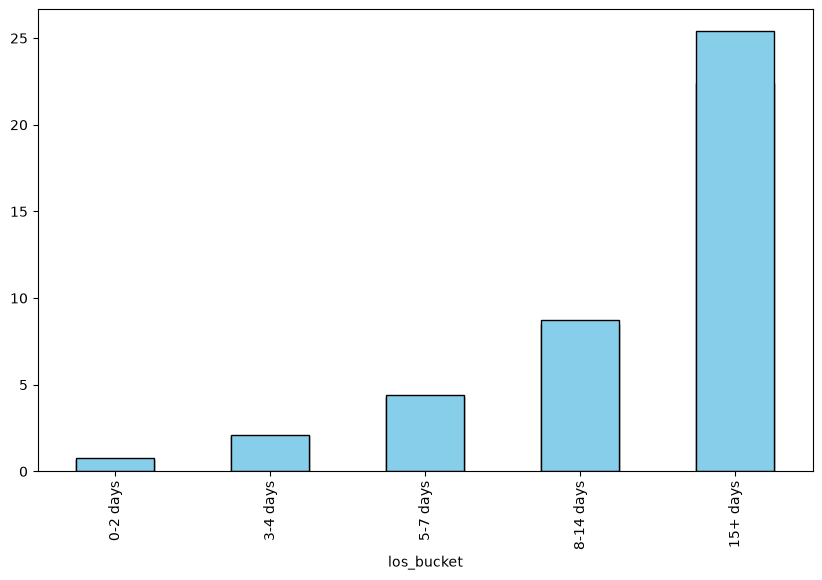

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

summary['mae'].plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')

# los of 15 days is messing up our accuracy/ mae

# As patients stay longer, our model is less acccurate


In [ ]:
print("y_train stats:")
print(y_train.describe())
print("\ny_test stats:")
print(y_test.describe())


# Checking for transformation issues
print("\nRaw predictions on training data:")
train_preds = model.predict(X_train)
print(pd.Series(train_preds).describe())
print("\nCompare to y_train:")
print(y_train.describe())

# Real problem, training on raw predictions, the minimum value is negative (staying for negative days doesn't make sense)

y_train stats:
count    75382.000000
mean         3.613869
std          5.360309
min          0.001250
25%          1.094899
50%          1.963860
75%          3.852347
max        226.403079
Name: los, dtype: float64

y_test stats:
count    19062.000000
mean         3.693913
std          5.565772
min          0.004954
25%          1.101189
50%          1.970793
75%          3.907459
max        159.666806
Name: los, dtype: float64

Raw predictions on training data:
count    75382.000000
mean         0.755841
std          0.423174
min         -0.874512
25%          0.464919
50%          0.695371
75%          0.996831
max          3.140058
dtype: float64

Compare to y_train:
count    75382.000000
mean         3.613869
std          5.360309
min          0.001250
25%          1.094899
50%          1.963860
75%          3.852347
max        226.403079
Name: los, dtype: float64


In [ ]:
check = np.log1p(y_train)
print(check.describe())

# both "logged"

count    75382.000000
mean         1.235506
std          0.673303
min          0.001249
25%          0.739505
50%          1.086492
75%          1.579462
max          5.426724
Name: los, dtype: float64


In [26]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Sanity check: should now look like raw LOS days, similar scale to y_test
print(pd.Series(y_pred).describe())



count    19062.000000
mean         1.349132
std          1.247602
min         -0.562196
25%          0.592759
50%          1.008354
75%          1.701116
max         17.339600
dtype: float64


In [28]:
#get rid of negative predictions:

y_pred = np.clip(y_pred, 0, None)

In [30]:
y_pred = np.clip(np.expm1(model.predict(X_test)), 0, None)

#Analyze error using data set

error_df = pd.DataFrame({'actual_los': y_test, 'predicted_los': y_pred})

error_df['error'] = error_df['actual_los'] - error_df['predicted_los'] #Is it underpredicting or overpredicting?
error_df['abs_error'] = error_df['error'].abs() # Exactly how far away


bins = [0, 2, 4, 7, 14, np.inf]
labels = ['0-2 days', '3-4 days', '5-7 days', '8-14 days', '15+ days']
error_df['los_bucket'] = pd.cut(error_df['actual_los'], bins=bins, labels=labels)

# Compute residuals per bucket

def rmse(x):
    return np.sqrt(np.mean(x**2).mean())



summary = error_df.groupby('los_bucket').agg(
    n_patients=('actual_los', 'count'),
    avg_actual_los=('actual_los', 'mean'),
    avg_predicted_los=('predicted_los', 'mean'),
    mae=('abs_error', 'mean'),
    rmse=('error', rmse)
)

print(summary)


from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
print(f"\nOverall MAE: {mae:.2f}, RMSE: {rmse_val:.2f}, R²: {r2:.4f}")

            n_patients  avg_actual_los  avg_predicted_los        mae  \
los_bucket                                                             
0-2 days          9689        1.142870           0.974271   0.699601   
3-4 days          4753        2.798414           1.324956   1.656282   
5-7 days          2318        5.226270           1.746430   3.527502   
8-14 days         1466        9.629713           2.316045   7.365064   
15+ days           836       23.693290           3.093145  20.600145   

                 rmse  
los_bucket             
0-2 days     0.937425  
3-4 days     1.852761  
5-7 days     3.761600  
8-14 days    7.730146  
15+ days    23.775880  

Overall MAE: 2.67, RMSE: 5.69, R²: -0.0463


In [31]:
X_train.columns

Index(['anchor_age', 'age_at_admission', 'gender_binary', 'num_diagnoses',
       'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION',
       'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION',
       'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT',
       'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT',
       'admission_location_CLINIC REFERRAL',
       'admission_location_EMERGENCY ROOM',
       'admission_location_INFORMATION NOT AVAILABLE',
       'admission_location_INTERNAL TRANSFER TO OR FROM PSYCH',
       'admission_location_PACU', 'admission_location_PHYSICIAN REFERRAL',
       'admission_location_PROCEDURE SITE',
       'admission_location_TRANSFER FROM HOSPITAL',
       'admission_location_TRANSFER FROM SKILLED NURSING FACILITY',
       'admission_location_WALK-IN/SELF REFERRAL', 'insurance_Medicare',
       'insurance_No charge', 'insurance_Other', 'insurance_Private',
       'marital_status_MARRIED', 'marital_sta

In [36]:
import os

base = "E:/mimic-iv/mimic-iv-3.1/hosp"
for root, dirs, files in os.walk(base):
    # only show top 2 levels to avoid a huge dump
    depth = root[len(base):].count(os.sep)
    if depth < 2:
        print(root)
        for f in files:
            print("   ", f)

E:/mimic-iv/mimic-iv-3.1/hosp
    admissions.csv.gz
    diagnoses_icd.csv.gz
    drgcodes.csv.gz
    d_hcpcs.csv.gz
    d_icd_diagnoses.csv.gz
    d_icd_procedures.csv.gz
    d_labitems.csv.gz
    emar.csv.gz
    emar_detail.csv.gz
    hcpcsevents.csv.gz
    labevents.csv.gz
    microbiologyevents.csv.gz
    omr.csv.gz
    patients.csv.gz
    pharmacy.csv.gz
    poe.csv.gz
    poe_detail.csv.gz
    prescriptions.csv.gz
    procedures_icd.csv.gz
    provider.csv.gz
    services.csv.gz
    transfers.csv.gz


In [35]:
import os

base = "E:/mimic-iv/mimic-iv-3.1/icu"
for root, dirs, files in os.walk(base):
    # only show top 2 levels to avoid a huge dump
    depth = root[len(base):].count(os.sep)
    if depth < 2:
        print(root)
        for f in files:
            print("   ", f)

E:/mimic-iv/mimic-iv-3.1/icu
    caregiver.csv.gz
    chartevents.csv.gz
    datetimeevents.csv.gz
    d_items.csv.gz
    icustays.csv.gz
    ingredientevents.csv.gz
    inputevents.csv.gz
    outputevents.csv.gz
    procedureevents.csv.gz


In [37]:
import pandas as pd

base = "E:/mimic-iv/mimic-iv-3.1"

# --- Vitals: search chartevents item dictionary ---
d_items = pd.read_csv(f"{base}/icu/d_items.csv.gz")

vital_keywords = ['heart rate', 'respiratory rate', 'systolic', 'diastolic', 
                   'temperature', 'oxygen saturation', 'spo2', 'glasgow coma']

for kw in vital_keywords:
    matches = d_items[d_items['label'].str.contains(kw, case=False, na=False)]
    print(f"\n--- '{kw}' ---")
    print(matches[['itemid', 'label', 'category']].head(10))



# --- Labs: search labevents item dictionary ---
d_labitems = pd.read_csv(f"{base}/hosp/d_labitems.csv.gz")

lab_keywords = ['creatinine', 'bun', 'white blood cell', 'hemoglobin', 
                'platelet', 'sodium', 'potassium', 'glucose', 'lactate', 'bicarbonate']

for kw in lab_keywords:
    matches = d_labitems[d_labitems['label'].str.contains(kw, case=False, na=False)]
    print(f"\n--- '{kw}' ---")
    print(matches[['itemid', 'label', 'fluid', 'category']].head(10))


--- 'heart rate' ---
   itemid                    label             category
2  220045               Heart Rate  Routine Vital Signs
3  220046  Heart rate Alarm - High               Alarms
4  220047   Heart Rate Alarm - Low               Alarms

--- 'respiratory rate' ---
     itemid                           label     category
28   220210                Respiratory Rate  Respiratory
799  224688          Respiratory Rate (Set)  Respiratory
800  224689  Respiratory Rate (spontaneous)  Respiratory
801  224690        Respiratory Rate (Total)  Respiratory

--- 'systolic' ---
      itemid                                         label  \
6     220050              Arterial Blood Pressure systolic   
11    220059            Pulmonary Artery Pressure systolic   
24    220179          Non Invasive Blood Pressure systolic   
575   224167           Manual Blood Pressure Systolic Left   
1212  225309                               ART BP Systolic   
1995  226850                 RV systolic pressure

In [38]:
extra_keywords = ['pulse ox', 'urea nitrogen']

for kw in extra_keywords:
    matches = d_labitems[d_labitems['label'].str.contains(kw, case=False, na=False)]
    print(f"\n--- '{kw}' (labs) ---")
    print(matches[['itemid', 'label', 'fluid', 'category']].head(10))

for kw in ['pulse ox', 'gcs']:
    matches = d_items[d_items['label'].str.contains(kw, case=False, na=False)]
    print(f"\n--- '{kw}' (chart) ---")
    print(matches[['itemid', 'label', 'category']].head(10))


--- 'pulse ox' (labs) ---
Empty DataFrame
Columns: [itemid, label, fluid, category]
Index: []

--- 'urea nitrogen' (labs) ---
      itemid                       label                fluid   category
49     50851      Urea Nitrogen, Ascites              Ascites  Chemistry
202    51006               Urea Nitrogen                Blood  Chemistry
233    51045   Urea Nitrogen, Body Fluid     Other Body Fluid  Chemistry
292    51104        Urea Nitrogen, Urine                Urine  Chemistry
920    51804          Urea Nitrogen, CSF  Cerebrospinal Fluid  Chemistry
941    51825  Urea Nitrogen, Joint Fluid          Joint Fluid  Chemistry
1013   51922      Urea Nitrogen, Pleural              Pleural  Chemistry
1042   51951        Urea Nitrogen, Stool                Stool  Chemistry
1529   52647               Urea Nitrogen                Blood  Chemistry

--- 'pulse ox' (chart) ---
Empty DataFrame
Columns: [itemid, label, category]
Index: []

--- 'gcs' (chart) ---
      itemid                   

In [39]:
for kw in ['o2 saturation', 'sao2', 'sat']:
    matches = d_items[d_items['label'].str.contains(kw, case=False, na=False)]
    print(f"\n--- '{kw}' (chart) ---")
    print(matches[['itemid', 'label', 'category']].head(15))


--- 'o2 saturation' (chart) ---
      itemid                                     label           category
31    220227                    Arterial O2 Saturation               Labs
36    220277               O2 saturation pulseoxymetry        Respiratory
345   223769  O2 Saturation Pulseoxymetry Alarm - High             Alarms
346   223770   O2 Saturation Pulseoxymetry Alarm - Low             Alarms
2004  226860               RA %O2 Saturation (PA Line)  PA Line Insertion
2005  226861              ART %O2 saturation (PA Line)  PA Line Insertion
2006  226862               PA %O2 Saturation (PA Line)  PA Line Insertion
2007  226863              PVR %O2 Saturation (PA Line)  PA Line Insertion
2008  226865              SVR %O2 Saturation (PA Line)  PA Line Insertion

--- 'sao2' (chart) ---
     itemid               label     category
825  224719  SaO2 < 90% > 2 min  Respiratory

--- 'sat' (chart) ---
      itemid                                     label       category
31    220227        

In [40]:
base = "E:/mimic-iv/mimic-iv-3.1"

icustays = pd.read_csv(f"{base}/icu/icustays.csv.gz", parse_dates=['intime', 'outtime'])
icustays['window_end'] = icustays['intime'] + pd.Timedelta(hours=24)

cohort = icustays[['subject_id', 'hadm_id', 'stay_id', 'intime', 'window_end']].copy()
print(cohort.shape)
print(cohort.head())

# Now we have a cohort of ICU stays with a 24-hour window for feature extraction. 
# The next steps would typically involve merging this cohort with relevant clinical data (vitals, labs, etc.) to create a feature matrix for modeling.

(94458, 5)
   subject_id   hadm_id   stay_id              intime          window_end
0    10000032  29079034  39553978 2180-07-23 14:00:00 2180-07-24 14:00:00
1    10000690  25860671  37081114 2150-11-02 19:37:00 2150-11-03 19:37:00
2    10000980  26913865  39765666 2189-06-27 08:42:00 2189-06-28 08:42:00
3    10001217  24597018  37067082 2157-11-20 19:18:02 2157-11-21 19:18:02
4    10001217  27703517  34592300 2157-12-19 15:42:24 2157-12-20 15:42:24


In [ ]:
vital_itemids = [220045, 220210, 220179, 220180, 223762, 220277, 220739, 223900, 223901]

# Keep only what we need from cohort for the merge
cohort_chart = cohort[['stay_id', 'intime', 'window_end']]

chunks_collected = []
chunksize = 5_000_000  

reader = pd.read_csv(
    f"{base}/icu/chartevents.csv.gz",
    usecols=['stay_id', 'itemid', 'charttime', 'valuenum'],
    parse_dates=['charttime'],
    chunksize=chunksize
)

for i, chunk in enumerate(reader):
    # Filter to only our itemids first (cheap, reduces rows fast)
    chunk = chunk[chunk['itemid'].isin(vital_itemids)]
    if chunk.empty:
        print(f"chunk {i}: 0 matching rows")
        continue

    # Merge with cohort to get each patient's window
    merged = chunk.merge(cohort_chart, on='stay_id', how='inner')

    # Keep only rows within the first 24 hours
    merged = merged[(merged['charttime'] >= merged['intime']) & 
                     (merged['charttime'] <= merged['window_end'])]

    if not merged.empty:
        chunks_collected.append(merged[['stay_id', 'itemid', 'charttime', 'valuenum']])

    print(f"chunk {i}: {len(merged)} matching rows kept")

vitals_raw = pd.concat(chunks_collected, ignore_index=True)
print(vitals_raw.shape)

chunk 0: 148600 matching rows kept
chunk 1: 141267 matching rows kept
chunk 2: 142320 matching rows kept
chunk 3: 144245 matching rows kept
chunk 4: 164903 matching rows kept
chunk 5: 137543 matching rows kept
chunk 6: 141371 matching rows kept
chunk 7: 136497 matching rows kept
chunk 8: 166179 matching rows kept
chunk 9: 157891 matching rows kept
chunk 10: 136404 matching rows kept
chunk 11: 129759 matching rows kept
chunk 12: 141204 matching rows kept
chunk 13: 141417 matching rows kept
chunk 14: 137125 matching rows kept
chunk 15: 152099 matching rows kept
chunk 16: 138093 matching rows kept
chunk 17: 133744 matching rows kept
chunk 18: 146444 matching rows kept
chunk 19: 146038 matching rows kept
chunk 20: 159862 matching rows kept
chunk 21: 154237 matching rows kept
chunk 22: 158909 matching rows kept
chunk 23: 134169 matching rows kept
chunk 24: 134608 matching rows kept
chunk 25: 153618 matching rows kept
chunk 26: 148888 matching rows kept
chunk 27: 143096 matching rows kept
ch

In [42]:
preview = pd.read_csv(f"{base}/icu/chartevents.csv.gz", nrows=5)
print(preview.columns.tolist())
print(preview.head())

['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime', 'storetime', 'itemid', 'value', 'valuenum', 'valueuom', 'warning']
   subject_id   hadm_id   stay_id  caregiver_id            charttime  \
0    10000032  29079034  39553978         18704  2180-07-23 12:36:00   
1    10000032  29079034  39553978         18704  2180-07-23 12:36:00   
2    10000032  29079034  39553978         18704  2180-07-23 12:36:00   
3    10000032  29079034  39553978         18704  2180-07-23 14:00:00   
4    10000032  29079034  39553978         18704  2180-07-23 14:00:00   

             storetime  itemid              value  valuenum valueuom  warning  
0  2180-07-23 14:45:00  226512               39.4      39.4       kg        0  
1  2180-07-23 14:45:00  226707                 60      60.0     Inch        0  
2  2180-07-23 14:45:00  226730                152     152.0       cm        0  
3  2180-07-23 14:18:00  220048  SR (Sinus Rhythm)       NaN      NaN        0  
4  2180-07-23 14:18:00  224642    

## Step 3: Extracting First-24-Hour Clinical Features

### The problem with our current model
Our baseline model only uses demographic/admin data (age, insurance, admission type, etc.) — 
it has no idea how *sick* a patient actually is. That's why it barely beats a naive guess.

### The fix: add clinical severity signal
We want to add real vitals and labs (heart rate, blood pressure, creatinine, lactate, etc.) 
so the model can tell the difference between a stable patient and a critically ill one.

### Why only the first 24 hours?
We can only use information a doctor would actually have *at the time* they'd want a 
prediction — right after a patient enters the ICU. Using data from day 3 or day 5 would be 
"cheating," since we wouldn't have that information yet in a real scenario.

### The challenge: MIMIC stores data differently than you'd expect
- `chartevents` (vitals) and `labevents` (labs) don't have a column for each measurement type 
  (like `heart_rate` or `creatinine`).
- Instead, every measurement is a **row**, tagged with a code (`itemid`) saying *what* was 
  measured, plus a timestamp and the value.
- So to get heart rate, we don't look for a `heart_rate` column — we filter rows down to 
  `itemid == 220045`.

### Step-by-step plan
1. **Find the right itemids** — searched `d_items`/`d_labitems` (small lookup tables) to find 
   the code numbers for the 9 vitals/GCS components and 9 labs we care about.
2. **Build the "cohort" table** — one row per ICU stay, with each patient's admission time 
   (`intime`) and their personal 24-hour cutoff (`window_end = intime + 24 hours`). This defines 
   *whose* data counts and *which time range* counts, per patient.
3. **Read the giant files in chunks** — `chartevents`/`labevents` are too large to load all at 
   once, so we read them a few million rows at a time, filtering each chunk down to just our 
   itemids before moving to the next chunk (keeps memory usage low and avoids crashing the kernel).
4. **Match each row to its patient's window** — merge on `stay_id`/`hadm_id`, then keep only 
   rows where the measurement's timestamp falls between that patient's `intime` and `window_end`.
5. **Combine survivors from all chunks** — stack up the small filtered pieces from every chunk 
   into one clean dataset: just the vitals/labs that happened in each patient's first 24 hours.

### What's next after this
Once extraction is done, we'll aggregate this raw data into **one row per patient** 
(e.g., min/max/mean heart rate, worst GCS, max lactate, etc.) and merge it into `X_train`/`X_test` 
as new columns — then retrain the model and see if these features actually help.

In [43]:
print(vitals_raw.shape)
print(vitals_raw['itemid'].value_counts())
print(vitals_raw.head())

(12598870, 4)
itemid
220045    2446684
220210    2416983
220277    2388814
220179    1622555
220180    1622200
220739     657317
223900     655831
223901     654086
223762     134400
Name: count, dtype: int64
    stay_id  itemid           charttime  valuenum
0  39553978  220179 2180-07-23 14:11:00      84.0
1  39553978  220180 2180-07-23 14:11:00      48.0
2  39553978  220045 2180-07-23 14:12:00      91.0
3  39553978  220210 2180-07-23 14:12:00      24.0
4  39553978  220277 2180-07-23 14:13:00      98.0


In [44]:
# Pivot: one row per stay_id, one column per itemid, with min/max/mean aggregated
vitals_agg = vitals_raw.groupby(['stay_id', 'itemid'])['valuenum'].agg(['min', 'max', 'mean']).reset_index()

print(vitals_agg.shape)
print(vitals_agg.head(10))

(744327, 5)
    stay_id  itemid    min    max        mean
0  30000153  220045   83.0  128.0  106.840000
1  30000153  220179  113.0  158.0  137.111111
2  30000153  220180   56.0   83.0   72.000000
3  30000153  220210   10.0   22.0   15.076923
4  30000153  220277   92.0  100.0   96.640000
5  30000153  220739    3.0    4.0    3.312500
6  30000153  223900    1.0    5.0    3.187500
7  30000153  223901    5.0    6.0    5.812500
8  30000213  220045   66.0   91.0   81.680000
9  30000213  220179  116.0  168.0  134.920000


In [45]:
vitals_agg.head(10)

,stay_id,itemid,min,max,mean
0,30000153,220045,83.0,128.0,106.840000
1,30000153,220179,113.0,158.0,137.111111
2,30000153,220180,56.0,83.0,72.000000
3,30000153,220210,10.0,22.0,15.076923
4,30000153,220277,92.0,100.0,96.640000
5,30000153,220739,3.0,4.0,3.312500
6,30000153,223900,1.0,5.0,3.187500
7,30000153,223901,5.0,6.0,5.812500
8,30000213,220045,66.0,91.0,81.680000
9,30000213,220179,116.0,168.0,134.920000


In [46]:
# Map itemids to readable names first
itemid_names = {
    220045: 'heart_rate',
    220210: 'resp_rate',
    220179: 'sbp',
    220180: 'dbp',
    223762: 'temp_c',
    220277: 'spo2',
    220739: 'gcs_eye',
    223900: 'gcs_verbal',
    223901: 'gcs_motor',
}

vitals_agg['itemid_name'] = vitals_agg['itemid'].map(itemid_names)

# Pivot to wide format
vitals_wide = vitals_agg.pivot(index='stay_id', columns='itemid_name', values=['min', 'max', 'mean'])

# Flatten the multi-level column names (e.g. ('min','heart_rate') -> 'heart_rate_min')
vitals_wide.columns = [f"{stat}_{name}" for stat, name in vitals_wide.columns]
vitals_wide = vitals_wide.reset_index()

print(vitals_wide.shape)
print(vitals_wide.columns.tolist())
print(vitals_wide.head())


vitals_wide['gcs_total_min'] = (
    vitals_wide['min_gcs_eye'].fillna(0) + 
    vitals_wide['min_gcs_verbal'].fillna(0) + 
    vitals_wide['min_gcs_motor'].fillna(0)
)
# Note: fillna(0) here is just to allow summing; we'll revisit missing-GCS patients separately

(94361, 28)
['stay_id', 'min_dbp', 'min_gcs_eye', 'min_gcs_motor', 'min_gcs_verbal', 'min_heart_rate', 'min_resp_rate', 'min_sbp', 'min_spo2', 'min_temp_c', 'max_dbp', 'max_gcs_eye', 'max_gcs_motor', 'max_gcs_verbal', 'max_heart_rate', 'max_resp_rate', 'max_sbp', 'max_spo2', 'max_temp_c', 'mean_dbp', 'mean_gcs_eye', 'mean_gcs_motor', 'mean_gcs_verbal', 'mean_heart_rate', 'mean_resp_rate', 'mean_sbp', 'mean_spo2', 'mean_temp_c']
    stay_id  min_dbp  min_gcs_eye  min_gcs_motor  min_gcs_verbal  \
0  30000153     56.0          3.0            5.0             1.0   
1  30000213     47.0          2.0            4.0             1.0   
2  30000484     23.0          3.0            1.0             1.0   
3  30000646     34.0          4.0            6.0             5.0   
4  30000831     50.0          3.0            4.0             1.0   

   min_heart_rate  min_resp_rate  min_sbp  min_spo2  min_temp_c  ...  \
0            83.0           10.0    113.0      92.0         NaN  ...   
1            66

In [47]:
vitals_wide['min_gcs_total'] = (
    vitals_wide['min_gcs_eye'] + 
    vitals_wide['min_gcs_verbal'] + 
    vitals_wide['min_gcs_motor']
)

In [49]:
for name in ['df', 'df_encoded', 'model_df']:
    d = eval(name)
    print(f"{name}: has stay_id = {'stay_id' in d.columns}, shape = {d.shape}")

df: has stay_id = True, shape = (94458, 31)
df_encoded: has stay_id = True, shape = (94458, 74)
model_df: has stay_id = False, shape = (94444, 54)


In [50]:
# Step 1: merge vitals onto df_encoded (which still has stay_id)
df_encoded_v2 = df_encoded.merge(vitals_wide, on='stay_id', how='left')
print(df_encoded.shape, df_encoded_v2.shape)

(94458, 74) (94458, 103)


In [51]:
drop_cols = ['subject_id', 'hadm_id', 'stay_id', 'last_careunit', 'discharge_location',
             'language', 'race', 'admit_provider_id', 'gender',
             'intime', 'outtime', 'admittime', 'dischtime', 'deathtime', 'dod',
             'edregtime', 'edouttime', 'anchor_year', 'anchor_year_group',
             'hospital_expire_flag']

model_df = df_encoded.drop(columns=drop_cols)

bool_cols = model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

In [53]:
from sklearn.model_selection import GroupShuffleSplit


bad_mask = model_df['los'].isna() | np.isinf(model_df['los'])
model_df = model_df[~bad_mask]

groups = df_encoded.loc[model_df.index, 'subject_id']

X = model_df.drop(columns=['los'])
y = model_df['los']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [54]:
# 1. Merge vitals onto df_encoded (still has stay_id here)
df_encoded_v2 = df_encoded.merge(vitals_wide, on='stay_id', how='left')
print(df_encoded.shape, '->', df_encoded_v2.shape)

# 2. Reapply the exact same drop_cols logic
model_df = df_encoded_v2.drop(columns=drop_cols)

bool_cols = model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

print('model_df shape:', model_df.shape)  # should be 94458 x (54 + new vital cols)

# 3. Drop bad LOS rows (same as before)
bad_mask = model_df['los'].isna() | np.isinf(model_df['los'])
print(f'dropping {bad_mask.sum()} bad-LOS rows')
model_df = model_df[~bad_mask]

# 4. Same group-based split, same random_state — reproducible vs. your original split
groups = df_encoded_v2.loc[model_df.index, 'subject_id']

X = model_df.drop(columns=['los'])
y = model_df['los']

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f'patients in both train and test: {len(overlap)}')  # want 0

(94458, 74) -> (94458, 103)
model_df shape: (94458, 83)
dropping 14 bad-LOS rows
patients in both train and test: 0


In [55]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model_v2 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_v2.fit(X_train, y_train_log)

z_pred = model_v2.predict(X_test)
y_pred = np.exp(z_pred)
y_pred = np.clip(y_pred, 0, None)  # no negative LOS days

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"NEW MAE:  {mae:.2f} days   (old: 2.67, baseline mean: 3.01, baseline median: 2.57)")
print(f"NEW RMSE: {rmse:.2f} days   (old: 5.69, baseline mean: 5.57)")
print(f"NEW R²:   {r2:.4f}          (old: -0.0463)")

NEW MAE:  2.12 days   (old: 2.67, baseline mean: 3.01, baseline median: 2.57)
NEW RMSE: 5.01 days   (old: 5.69, baseline mean: 5.57)
NEW R²:   0.1892          (old: -0.0463)


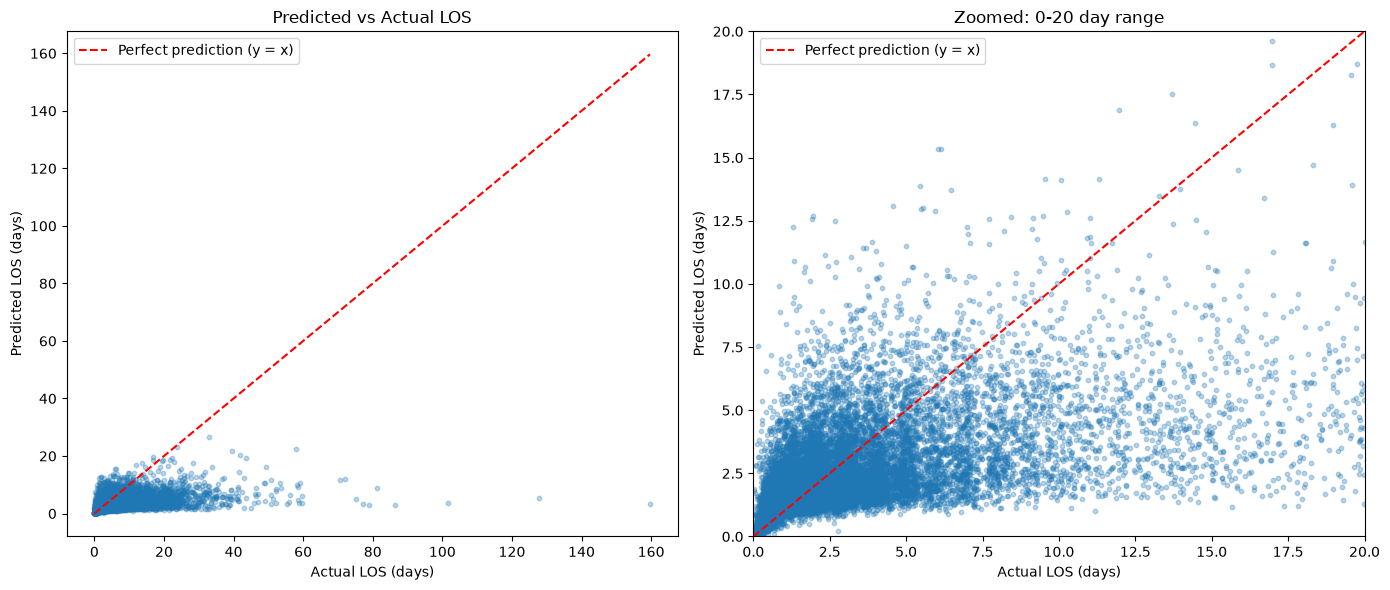

In [56]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Predicted vs Actual scatter ---
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=10)

# Perfect-prediction reference line (y = x)
max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction (y = x)')

ax.set_xlabel('Actual LOS (days)')
ax.set_ylabel('Predicted LOS (days)')
ax.set_title('Predicted vs Actual LOS')
ax.legend()

# --- Plot 2: Zoomed in on the bulk of the data (0-20 days) ---
# Long tail (some stays are 100+ days) squishes the main cluster visually, so zoom in
ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.3, s=10)
ax2.plot([0, 20], [0, 20], 'r--', label='Perfect prediction (y = x)')
ax2.set_xlim(0, 20)
ax2.set_ylim(0, 20)
ax2.set_xlabel('Actual LOS (days)')
ax2.set_ylabel('Predicted LOS (days)')
ax2.set_title('Zoomed: 0-20 day range')
ax2.legend()

plt.tight_layout()
plt.show()

## What This Graph Is Telling Us (Plain English)

**The red dashed line = "perfect prediction."** If a dot sits exactly on that line, 
the model called that patient's stay exactly right. The closer the dots hug the line, 
the better the model is doing.

**What we should see:**
- For **short stays** (a few days), the dots should cluster fairly close to the line — 
  the model is decent at spotting "this person will be in and out quickly."
- For **long stays** (patients who end up in the ICU for a couple weeks or more), 
  the dots likely sit **below** the line — meaning the model predicted a shorter 
  stay than what actually happened. In other words: **the model still struggles to 
  recognize when someone is going to be a long, difficult case.**

### Why this makes sense
This matches exactly what we found earlier in the bucket table — patients with 15+ day 
stays were the group our model handled worst, even after adding vitals. Vitals help the 
model catch "sicker vs. healthier" in general, but truly extreme, unusual cases (very long 
stays) are rare in the data, so the model hasn't seen enough of them to learn that pattern well.

### The headline win
Compared to before adding vitals:
- **MAE dropped from 2.67 → 2.12 days** (predictions are, on average, about half a day closer 
  to the truth)
- **R² went from -0.05 → 0.19** — this is the big one. Negative R² meant the model was 
  *worse than just guessing the average for everyone*. Positive R² means the model is now 
  **actually learning something real and useful** about patients, for the first time in 
  this project.

### Bottom line
Adding real clinical data (vitals) instead of just demographics was the right move — it 
turned a model that was *actively unhelpful* into one that's *meaningfully better than 
guessing*. The next opportunity is the labs (creatinine, lactate, WBC, etc.), which should 
give the model even more insight into how sick a patient really is — especially for those 
tricky long-stay cases.

In [57]:
lab_itemids = [50912, 51006, 51301, 51222, 51265, 50983, 50971, 50931, 50813, 50882]

cohort_lab = cohort[['hadm_id', 'stay_id', 'intime', 'window_end']]

chunks_collected = []
chunksize = 5_000_000

reader = pd.read_csv(
    f"{base}/hosp/labevents.csv.gz",
    usecols=['hadm_id', 'itemid', 'charttime', 'valuenum'],
    parse_dates=['charttime'],
    chunksize=chunksize
)

for i, chunk in enumerate(reader):
    chunk = chunk[chunk['itemid'].isin(lab_itemids)]
    chunk = chunk.dropna(subset=['hadm_id'])  # labs not tied to an admission are useless here
    if chunk.empty:
        print(f"chunk {i}: 0 matching rows")
        continue

    merged = chunk.merge(cohort_lab, on='hadm_id', how='inner')
    merged = merged[(merged['charttime'] >= merged['intime']) & 
                     (merged['charttime'] <= merged['window_end'])]

    if not merged.empty:
        chunks_collected.append(merged[['stay_id', 'itemid', 'charttime', 'valuenum']])

    print(f"chunk {i}: {len(merged)} matching rows kept")

labs_raw = pd.concat(chunks_collected, ignore_index=True)
print(labs_raw.shape)

chunk 0: 60610 matching rows kept
chunk 1: 59409 matching rows kept
chunk 2: 59835 matching rows kept
chunk 3: 59047 matching rows kept
chunk 4: 59636 matching rows kept
chunk 5: 58524 matching rows kept
chunk 6: 58063 matching rows kept
chunk 7: 55202 matching rows kept
chunk 8: 57300 matching rows kept
chunk 9: 57217 matching rows kept
chunk 10: 59332 matching rows kept
chunk 11: 59751 matching rows kept
chunk 12: 59288 matching rows kept
chunk 13: 59265 matching rows kept
chunk 14: 59591 matching rows kept
chunk 15: 56426 matching rows kept
chunk 16: 55574 matching rows kept
chunk 17: 58327 matching rows kept
chunk 18: 60453 matching rows kept
chunk 19: 55328 matching rows kept
chunk 20: 57473 matching rows kept
chunk 21: 57736 matching rows kept
chunk 22: 57133 matching rows kept
chunk 23: 58014 matching rows kept
chunk 24: 57210 matching rows kept
chunk 25: 62009 matching rows kept
chunk 26: 57645 matching rows kept
chunk 27: 57046 matching rows kept
chunk 28: 58189 matching rows 

In [58]:
labs_agg = labs_raw.groupby(['stay_id', 'itemid'])['valuenum'].agg(['min', 'max', 'mean']).reset_index()

lab_names = {
    50912: 'creatinine', 51006: 'bun', 51301: 'wbc', 51222: 'hemoglobin',
    51265: 'platelet', 50983: 'sodium', 50971: 'potassium',
    50931: 'glucose', 50813: 'lactate', 50882: 'bicarbonate',
}
labs_agg['itemid_name'] = labs_agg['itemid'].map(lab_names)

labs_wide = labs_agg.pivot(index='stay_id', columns='itemid_name', values=['min', 'max', 'mean'])
labs_wide.columns = [f"{stat}_{name}" for stat, name in labs_wide.columns]
labs_wide = labs_wide.reset_index()

print(labs_wide.shape)

(92118, 31)


In [59]:
df_encoded_v3 = df_encoded_v2.merge(labs_wide, on='stay_id', how='left')
print(df_encoded_v2.shape, '->', df_encoded_v3.shape)

model_df = df_encoded_v3.drop(columns=drop_cols)
bool_cols = model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

bad_mask = model_df['los'].isna() | np.isinf(model_df['los'])
model_df = model_df[~bad_mask]

groups = df_encoded_v3.loc[model_df.index, 'subject_id']
X = model_df.drop(columns=['los'])
y = model_df['los']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"model_df shape: {model_df.shape}")
print(f"overlap: {len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))}")  # want 0

(94458, 103) -> (94458, 133)
model_df shape: (94444, 113)
overlap: 0


In [60]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model_v3 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_v3.fit(X_train, y_train_log)

z_pred = model_v3.predict(X_test)
y_pred = np.clip(np.exp(z_pred), 0, None)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"MAE:  {mae:.2f} days   (vitals-only: 2.12, baseline: 2.57-3.01)")
print(f"RMSE: {rmse:.2f} days   (vitals-only: 5.01)")
print(f"R²:   {r2:.4f}          (vitals-only: 0.19)")

MAE:  2.10 days   (vitals-only: 2.12, baseline: 2.57-3.01)
RMSE: 4.99 days   (vitals-only: 5.01)
R²:   0.1963          (vitals-only: 0.19)


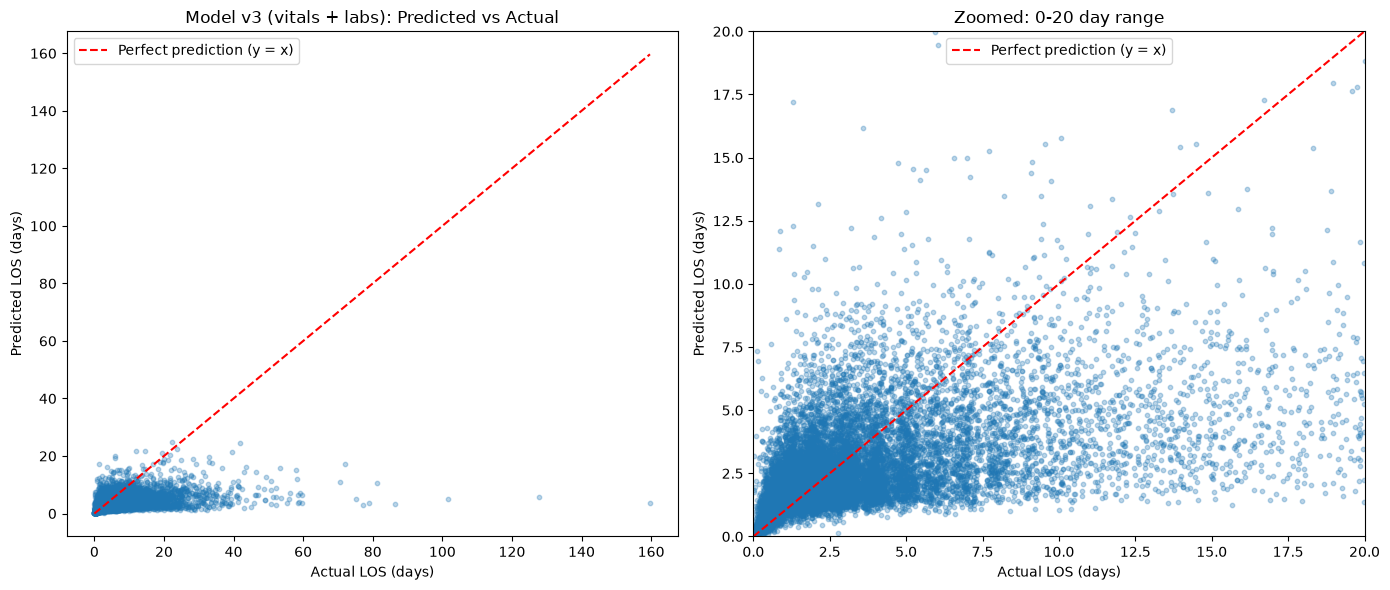

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Full range ---
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=10)
max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction (y = x)')
ax.set_xlabel('Actual LOS (days)')
ax.set_ylabel('Predicted LOS (days)')
ax.set_title('Model v3 (vitals + labs): Predicted vs Actual')
ax.legend()

# --- Plot 2: Zoomed 0-20 days ---
ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.3, s=10)
ax2.plot([0, 20], [0, 20], 'r--', label='Perfect prediction (y = x)')
ax2.set_xlim(0, 20)
ax2.set_ylim(0, 20)
ax2.set_xlabel('Actual LOS (days)')
ax2.set_ylabel('Predicted LOS (days)')
ax2.set_title('Zoomed: 0-20 day range')
ax2.legend()

plt.tight_layout()
plt.show()
# no significant improvement

In [62]:
# ============================================
# SAVE CHECKPOINT — run this before closing up
# ============================================
import pickle
import os

save_dir = r'E:\MedAgent\checkpoints'
os.makedirs(save_dir, exist_ok=True)

objects = {
    'df':              df,
    'df_encoded':      df_encoded,
    'df_encoded_v2':   df_encoded_v2,   # + merged vitals, still has stay_id
    'df_encoded_v3':   df_encoded_v3,   # + merged vitals AND labs, still has stay_id
    'model_df':        model_df,        # final feature matrix: demographics + vitals + labs, no IDs
    'model':           model,           # v1: demographics only
    'model_v2':        model_v2,        # v2: demographics + vitals
    'model_v3':        model_v3,        # v3: demographics + vitals + labs (current best)
    'X_train':         X_train,
    'X_test':          X_test,
    'y_train':         y_train,
    'y_test':          y_test,
    'y_pred':          y_pred,          # model_v3's predictions
    'groups':          groups,
    'dx_count':        dx_count,
    'vitals_wide':     vitals_wide,
    'labs_wide':       labs_wide,
}

for name, obj in objects.items():
    path = os.path.join(save_dir, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'saved: {path}')

print('\nall checkpoints saved.')

saved: E:\MedAgent\checkpoints\df.pkl
saved: E:\MedAgent\checkpoints\df_encoded.pkl
saved: E:\MedAgent\checkpoints\df_encoded_v2.pkl
saved: E:\MedAgent\checkpoints\df_encoded_v3.pkl
saved: E:\MedAgent\checkpoints\model_df.pkl
saved: E:\MedAgent\checkpoints\model.pkl
saved: E:\MedAgent\checkpoints\model_v2.pkl
saved: E:\MedAgent\checkpoints\model_v3.pkl
saved: E:\MedAgent\checkpoints\X_train.pkl
saved: E:\MedAgent\checkpoints\X_test.pkl
saved: E:\MedAgent\checkpoints\y_train.pkl
saved: E:\MedAgent\checkpoints\y_test.pkl
saved: E:\MedAgent\checkpoints\y_pred.pkl
saved: E:\MedAgent\checkpoints\groups.pkl
saved: E:\MedAgent\checkpoints\dx_count.pkl
saved: E:\MedAgent\checkpoints\vitals_wide.pkl
saved: E:\MedAgent\checkpoints\labs_wide.pkl

all checkpoints saved.


In [ ]:
# ==========================================================
# RUN THIS CELL NEXT TIME YOU COME BACK — loads everything
# ==========================================================
import pickle
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

save_dir = r'E:\MedAgent\checkpoints'

names = ['df', 'df_encoded', 'df_encoded_v2', 'df_encoded_v3', 'model_df',
         'model', 'model_v2', 'model_v3',
         'X_train', 'X_test', 'y_train', 'y_test', 'y_pred',
         'groups', 'dx_count', 'vitals_wide', 'labs_wide']

for name in names:
    path = os.path.join(save_dir, f'{name}.pkl')
    with open(path, 'rb') as f:
        globals()[name] = pickle.load(f)
    print(f'loaded: {name}')

print('\nall checkpoints loaded.')
print('Model v3 (vitals + labs): MAE 2.10 days, RMSE 4.99 days, R² 0.196')
print('Labs barely moved the needle vs vitals-only (R² 0.19) — plateauing.')
print('\nNext steps, in priority order:')
print('1. Run SHAP on model_v3 to see which features actually matter')
print('2. Try diagnosis-TYPE features (not just count) — likely biggest remaining lever')
print('3. Flag abnormal lab values directly (e.g. creatinine_high binary)')
print('4. Hyperparameter tuning (modest expected gain)')
print('5. Build the 30-day readmission classification model (same pipeline, new target)')